# Clasificación Automática de Noticias Mediante Técnicas de Machine Learning

**Materia:** Inteligencia Artificial 2026-1                                     
**Integrantes:** Martinez Uribe Juan Sebastian - Mosquera Molina Sergio Andres - Vergara Vergara Eduardo Enrique                                              
**Fecha de entrega:** 22 de Mayo de 2026  
**Dataset:** [News Category Classification Dataset — Kaggle](https://www.kaggle.com/datasets/bornaetminan/news-category-classification-dataset)

---
# BLOQUE I — Descripción del problema e inspección del conjunto de datos

## 1. Descripción del problema

### 1.1 Contexto y motivación

El crecimiento exponencial del contenido digital ha transformado la forma
en que se produce y consume información periodística. Según el informe
Digital News Report 2023 del Reuters Institute, más del 60% de los usuarios
accede a noticias a través de plataformas digitales, donde los sistemas de
recomendación y búsqueda dependen directamente de una categorización
precisa del contenido [1]. En este contexto, la clasificación manual de
artículos resulta inviable a escala: un portal de noticias de mediano tamaño
puede publicar cientos de artículos diarios en múltiples secciones temáticas,
lo que exige criterios consistentes, personal especializado y tiempos de
procesamiento incompatibles con la inmediatez del periodismo digital.

El Procesamiento de Lenguaje Natural (NLP) y el aprendizaje automático
ofrecen una solución viable a este problema. Trabajos como el de Zhang et al.
(2015) demostraron que modelos de clasificación de texto supervisados pueden
alcanzar niveles de precisión comparables a los anotadores humanos en tareas
de categorización de noticias [2], abriendo la puerta a la automatización
escalable de estos procesos.

### 1.2 Descripción del problema de clasificación

El problema abordado en este trabajo corresponde a una tarea de
**clasificación multiclase supervisada** sobre datos textuales. Dado un
artículo periodístico representado por su titular (`headline`) y descripción
corta (`short_description`), el objetivo es aprender una función
f: X → Y, donde X es el espacio de representaciones vectoriales del texto
e Y = {categoría₁, categoría₂, ..., categoríaₙ} es el conjunto de
etiquetas temáticas posibles.

Este problema presenta varios retos técnicos propios del dominio:

- **Alta dimensionalidad:** la representación vectorial del vocabulario genera
  espacios de miles de features, lo que requiere técnicas de selección de
  características.
- **Desbalance de clases:** algunas categorías concentran significativamente
  más artículos que otras, lo que puede sesgar el aprendizaje del modelo.
- **Ambigüedad semántica:** categorías como *Politics* y *Government*, o
  *Wellness* y *Healthy Living*, comparten vocabulario similar, dificultando
  la separación de las fronteras de decisión.

### 1.3 Objetivo del trabajo

Desarrollar un sistema de clasificación automática de noticias basado en
técnicas de aprendizaje supervisado, que a partir del contenido textual de
un artículo (titular y descripción corta) sea capaz de predecir su categoría
temática, evaluando y comparando el desempeño de múltiples algoritmos de
Machine Learning con el fin de determinar el modelo más efectivo para la
organización automatizada de contenido periodístico digital.

### 1.4 Objetivos específicos

- Analizar las características textuales del dataset e identificar patrones léxicos por categoría.
- Preprocesar los datos mediante técnicas de NLP (limpieza, normalización, vectorización TF-IDF) y selección de características con Chi-squared.
- Implementar y ajustar con `GridSearchCV` los siguientes modelos: Regresión Logística, Árbol de Decisión, Random Forest, MLP y DNN.
- Evaluar el desempeño con métricas de clasificación (accuracy, precision, recall, F1-score) y matrices de confusión.
- Comparar los modelos y determinar el más adecuado para la tarea de clasificación de noticias.



### 1.5 Variables del dataset

| Variable | Tipo | Rol | Descripción |
|---|---|---|---|
| `category` | Categórica | **Variable objetivo (y)** | Categoría temática de la noticia |
| `headline` | Texto | Feature principal | Titular del artículo |
| `short_description` | Texto | Feature principal | Resumen corto de la noticia |
| `authors` | Texto | Informativa | Autor(es) del artículo |
| `date` | Fecha | Informativa | Fecha de publicación |
| `link` | Texto | Informativa | URL original del artículo |


## 2. Librerías e Inspección del conjunto de datos (EDA)

### 2.1 Librerías utilizadas

| Librería | Módulo | Propósito |
|---|---|---|
| `pandas` | — | Manipulación y análisis de datos estructurados |
| `numpy` | — | Operaciones numéricas y manejo de arreglos |
| `re` | — | Limpieza de texto mediante expresiones regulares |
| `matplotlib` | `pyplot` | Generación de gráficas y visualizaciones |
| `seaborn` | — | Visualizaciones estadísticas de alto nivel |
| `wordcloud` | `WordCloud` | Generación de nubes de palabras por categoría |
| `nltk` | `word_tokenize` | Tokenización de texto en palabras individuales |
| `nltk` | `stopwords` | Corpus de palabras vacías en inglés para su eliminación |
| `nltk` | `WordNetLemmatizer` | Lematización: reducción de palabras a su forma base |




In [1]:
# ── Importaciones generales 
from pandas.plotting import scatter_matrix
import re
from IPython.display import display

# sklearn – preprocesamiento y vectorización
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.utils import resample
from sklearn.metrics.pairwise import cosine_similarity

# plots
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import numpy as np
import pandas as pd
import os
from datetime import datetime

# string / NLTK
import string
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ── Descargas necesarias ───────────────────────────────────────────────────
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')                      
nltk.download('averaged_perceptron_tagger_eng')
# Descargas NLTK necesarias
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

print('Librerías cargadas correctamente.')

# Imporatciones para modelado
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)
from sklearn.preprocessing import MaxAbsScaler
import warnings
import time
warnings.filterwarnings('ignore')

print("Librerías de modelado cargadas correctamente.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER-A315-59\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER-A315-59\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER-A315-59\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER-A315-59\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ACER-A315-59\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Librerías cargadas correctamente.
Librerías de modelado cargadas correctamente.



### 3.5 Balanceo del conjunto de datos

**Hallazgo en la inspección:** El gráfico de distribución de categorías mostró una disparidad marcada entre clases. Las categorías más frecuentes (como `POLITICS` o `WELLNESS`) tienen órdenes de magnitud más ejemplos que las minoritarias. Este desbalance hace que los clasificadores tiendan a predecir siempre la clase mayoritaria, inflando métricas globales y degradando el recall en clases pequeñas.

**Estrategia aplicada:** *Undersampling* aleatorio estratificado. Se define un techo máximo de registros por clase (`MAX_POR_CLASE`). Clases con más muestras se reducen aleatoriamente al umbral; clases por debajo del umbral se conservan completas. Esta estrategia:
- Reduce el tiempo de entrenamiento.
- Previene el sesgo hacia clases mayoritarias.
- Es preferible al oversampling sintético (SMOTE) para texto, pues SMOTE en espacio TF-IDF genera vectores poco realistas.

In [4]:
# ── Carga del dataset ────────────────────────────────────────────────────────

ARCHIVO = r"C:\Users\ACER-A315-59\OneDrive\Desktop\Proyecto final IA\Taller ML\Taller ML\archive\news_category_clean.csv"   

COLUMNA_OBJETIVO = 'category'
COLUMNA_TEXTO = 'clean_headline'
COLUMNA_NULL    = 'clean_description'
try:
    df = pd.read_csv(ARCHIVO)
    print(f"\n Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas")
    print(f"Total de categorías  : {resumen.shape[0]}")


except FileNotFoundError:
    print(f"\n  Archivo '{ARCHIVO}' no encontrado.")
    print("   Descarga el dataset de Kaggle y colócalo en esta carpeta.")
    print("   Luego cambia la variable ARCHIVO con el nombre correcto.")
    exit()

display(df.head(5))




 Dataset cargado: 206641 registros, 10 columnas
Total de categorías  : 42


,category,authors,date,clean_headline,clean_description,year,month,headline_char_count,headline_word_count,avg_word_length
0,U.S. NEWS,"Carla K. Johnson, AP",2022-09-23,over million americans roll up sleeves for omi...,health experts said it is too early to predict...,2022,9,73,10,7.300000
1,U.S. NEWS,Mary Papenfuss,2022-09-23,american airlines flyer charged banned for lif...,he was subdued by passengers and crew when he ...,2022,9,88,13,6.769231
2,COMEDY,Elyse Wanshel,2022-09-23,of the funniest tweets about cats and dogs thi...,until you have a dog you dont understand what ...,2022,9,57,11,5.181818
3,PARENTING,Caroline Bologna,2022-09-23,the funniest tweets from parents this week sept,accidentally put grownup toothpaste on my todd...,2022,9,47,8,5.875000
4,U.S. NEWS,Nina Golgowski,2022-09-22,woman who called cops on black birdwatcher los...,amy cooper accused investment firm franklin te...,2022,9,75,11,6.818182


In [3]:
resumen = (
    df.groupby(COLUMNA_OBJETIVO)
    .agg(Total=(COLUMNA_TEXTO, 'count'))
    .reset_index()
    .rename(columns={COLUMNA_OBJETIVO: 'Categoría'})
    .sort_values('Total', ascending=False)
    .reset_index(drop=True)
)
resumen.index = resumen.index + 1

styled = (
    resumen[['Categoría', 'Total']]
    .style
    .set_caption(" Distribución de Categorías")
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color', '#2E75B6'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px 12px')]},
        {'selector': 'td',
         'props': [('padding', '6px 14px'), ('border', '1px solid #d0d0d0'), ('font-size', '13px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', "#000000")]},
        {'selector': 'caption',
         'props': [('font-size', '15px'), ('font-weight', 'bold'), ('color', '#1a3a5c'), ('padding-bottom', '8px')]},
    ])
    .bar(subset=['Total'], color='#70AD47', vmin=0)
    .set_properties(**{'text-align': 'left'})
    .set_properties(subset=['Total'], **{'text-align': 'center'})
)

display(styled)
df.info()

,Categoría,Total
1,POLITICS,35163
2,WELLNESS,17544
3,ENTERTAINMENT,17286
4,TRAVEL,9850
5,STYLE & BEAUTY,9272
6,PARENTING,8606
7,HEALTHY LIVING,6642
8,FOOD & DRINK,6299
9,QUEER VOICES,6299
10,BUSINESS,5956


<class 'pandas.DataFrame'>
RangeIndex: 206641 entries, 0 to 206640
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   category             206641 non-null  str    
 1   authors              206641 non-null  str    
 2   date                 206641 non-null  str    
 3   clean_headline       206641 non-null  str    
 4   clean_description    186857 non-null  str    
 5   year                 206641 non-null  int64  
 6   month                206641 non-null  int64  
 7   headline_char_count  206641 non-null  int64  
 8   headline_word_count  206641 non-null  int64  
 9   avg_word_length      206641 non-null  float64
dtypes: float64(1), int64(4), str(5)
memory usage: 15.8 MB


In [9]:
# ── Valores nulos ────────────────────────────────────────────────────────────

nulos = df.isnull().sum()
df_nulos = pd.DataFrame({'Columna': nulos.index, 'Valores Nulos': nulos.values})



display(df_nulos.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #D3D3D3'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('border', '1px solid #D3D3D3'), ('padding', '10px')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', "#000000")]}
]))

,Columna,Valores Nulos
0,category,0
1,authors,0
2,date,0
3,clean_headline,0
4,clean_description,19784
5,year,0
6,month,0
7,headline_char_count,0
8,headline_word_count,0
9,avg_word_length,0


In [10]:
# ── Registros duplicados ─────────────────────────────────────────────────────
print(f'Registros duplicados: {df.duplicated().sum()}')

Registros duplicados: 0


### 2.2 Gráficas realizadas

#### 2.2.1 Gráfica 1: barras

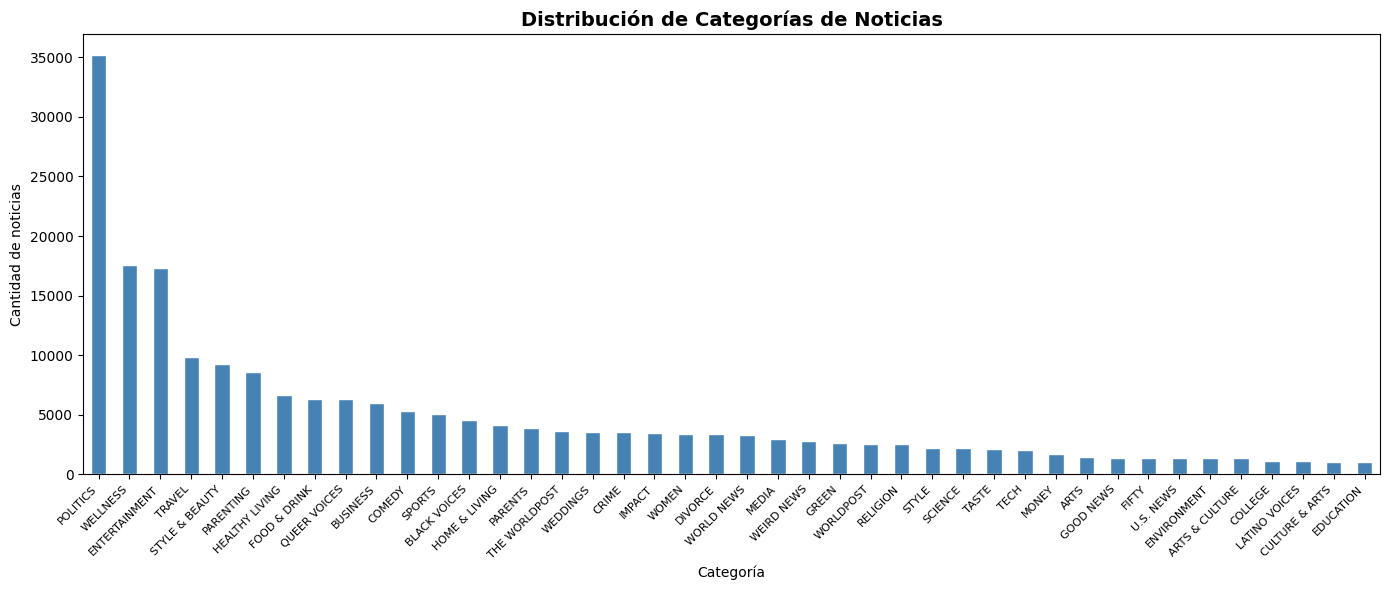

In [11]:
conteo = df['category'].value_counts()
plt.figure(figsize=(14, 6))
conteo.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribución de Categorías de Noticias', fontsize=14, fontweight='bold')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de noticias')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


#### 2.2.2 Gráfica 2: Torta (top 10) 

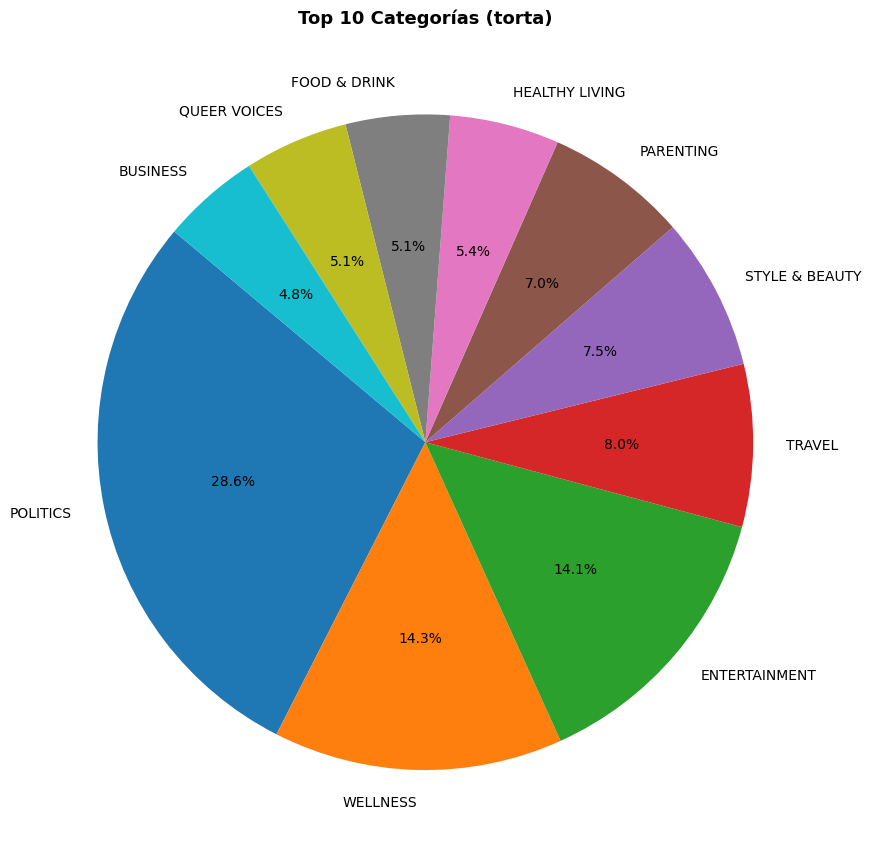

In [12]:

top10 = conteo.head(10)
plt.figure(figsize=(9, 9))
plt.pie(
top10.values,
        labels=top10.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('tab10')
    )
plt.title('Top 10 Categorías (torta)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


El dataset contiene **más de 40 categorías** con una distribución fuertemente desbalanceada.
**POLITICS** domina con el **28.6%** (~35,000 artículos), seguido de WELLNESS (14.3%) y
ENTERTAINMENT (14.1%), concentrando entre las tres más del **57% del total**.
En el extremo opuesto, categorías como EDUCATION o LATINO VOICES no superan los 1,000 artículos (<1%).



#### 2.2.3 Gráfica 3:  Matriz de correlación 

Categorías en la visualización: 42


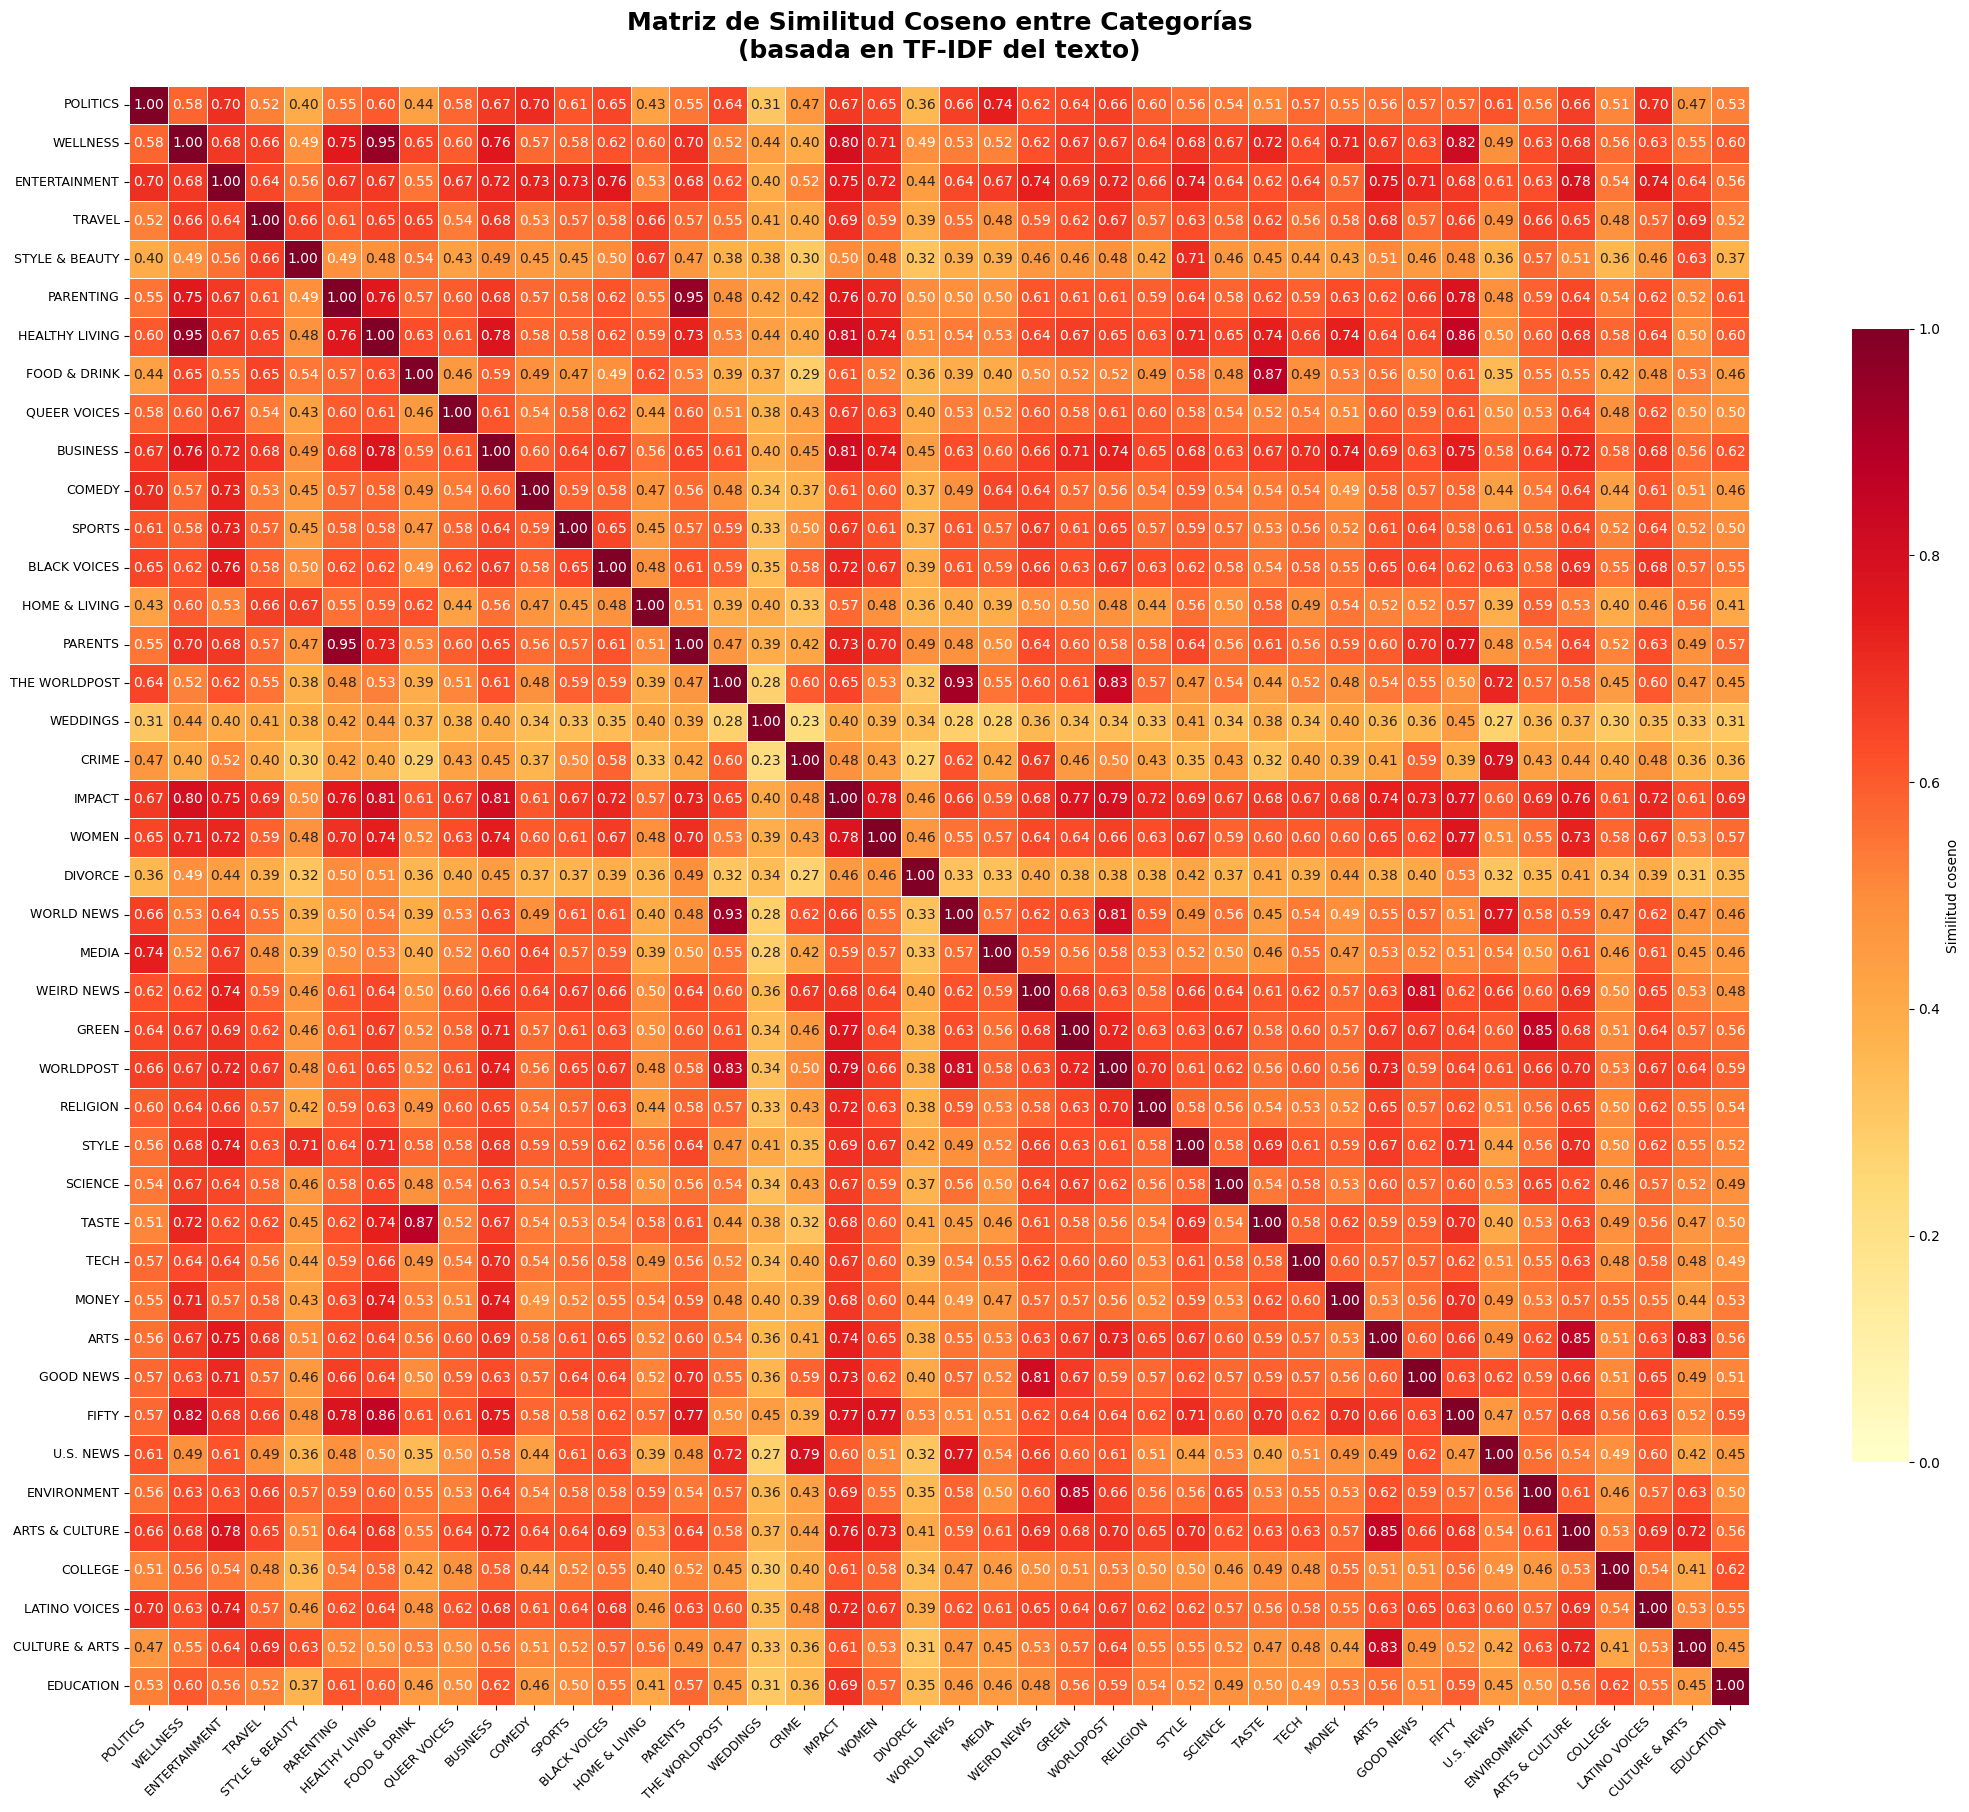

In [13]:
# ── Parámetros generales 

TOP_CATEGORIAS = df[COLUMNA_OBJETIVO].nunique()   
TOP_PALABRAS   = 20

# Filtrar las TOP_CATEGORIAS más frecuentes
cats_top = df[COLUMNA_OBJETIVO].value_counts().head(TOP_CATEGORIAS).index.tolist()
df_top   = df[df[COLUMNA_OBJETIVO].isin(cats_top)].copy()

print(f"Categorías en la visualización: {len(cats_top)}")  

tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vec.fit_transform(df_top[COLUMNA_TEXTO])

# ── Promedio de vectores TF-IDF por categoría
category_vectors = {}
for cat in cats_top:
    mask = df_top[COLUMNA_OBJETIVO] == cat
    cat_matrix = X_tfidf[mask.values]
    category_vectors[cat] = np.asarray(cat_matrix.mean(axis=0)).flatten()

# Matriz de similitud coseno entre categorías
cat_names  = list(category_vectors.keys())
cat_matrix = np.vstack(list(category_vectors.values()))
sim_matrix = cosine_similarity(cat_matrix)
sim_df = pd.DataFrame(sim_matrix, index=cat_names, columns=cat_names)

# ── Graficar 
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    sim_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",          
    vmin=0, vmax=1,         
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Similitud coseno", "shrink": 0.7},
    ax=ax
)
ax.set_title(
    "Matriz de Similitud Coseno entre Categorías\n(basada en TF-IDF del texto)",
    fontsize=18, fontweight="bold", pad=20
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Los valores oscilan entre **0.60 y 0.95**, indicando vocabulario periodístico compartido en todo el corpus. Los patrones más relevantes son:

| Par de categorías | Similitud | Interpretación |
|---|---|---|
| **PARENTING ↔ PARENTS** | **0.95** | Casi idénticas — deben fusionarse |
| **WELLNESS ↔ HEALTHY LIVING** | **0.95** | Casi idénticas — deben fusionarse |
| **WORLD NEWS ↔ THE WORLDPOST** | **0.93** | Solapamiento crítico de contenido internacional — deben fusionarse |
| **WORLDPOST ↔ THE WORLDPOST** | **0.83** | Redundancia de marca y temática — deben fusionarse |
| **FOOD & DRINK ↔ TASTE** | **0.87** | Vocabulario culinario compartido — deben fusionarse |
| **ARTS & CULTURE ↔ ARTS** | **0.85** | Fuerte intersección cultural y artística — deben fusionarse |
| **STYLE & BEAUTY ↔ STYLE** | **0.71** | Alta redundancia en moda y tendencias — deben fusionarse |
| POLITICS ↔ FOOD & DRINK | **0.44** | Mayor separación semántica (Patrón esperado) |
| HOME & LIVING ↔ SPORTS | **0.45** | Categorías bien diferenciadas (Patrón esperado) |


**Conclusiones:** 
- Fusionar las clases con Similitud mayor a 0.81 antes de entrenar.
- Con similitud de 0.97 ningún modelo podrá distinguirlas de forma confiable.
- El resto de categorías tienen separación semántica suficiente para clasificación independiente.

#### 2.2.4 Gráfica 4: histogramas de Longitud de Titulares por Categoría


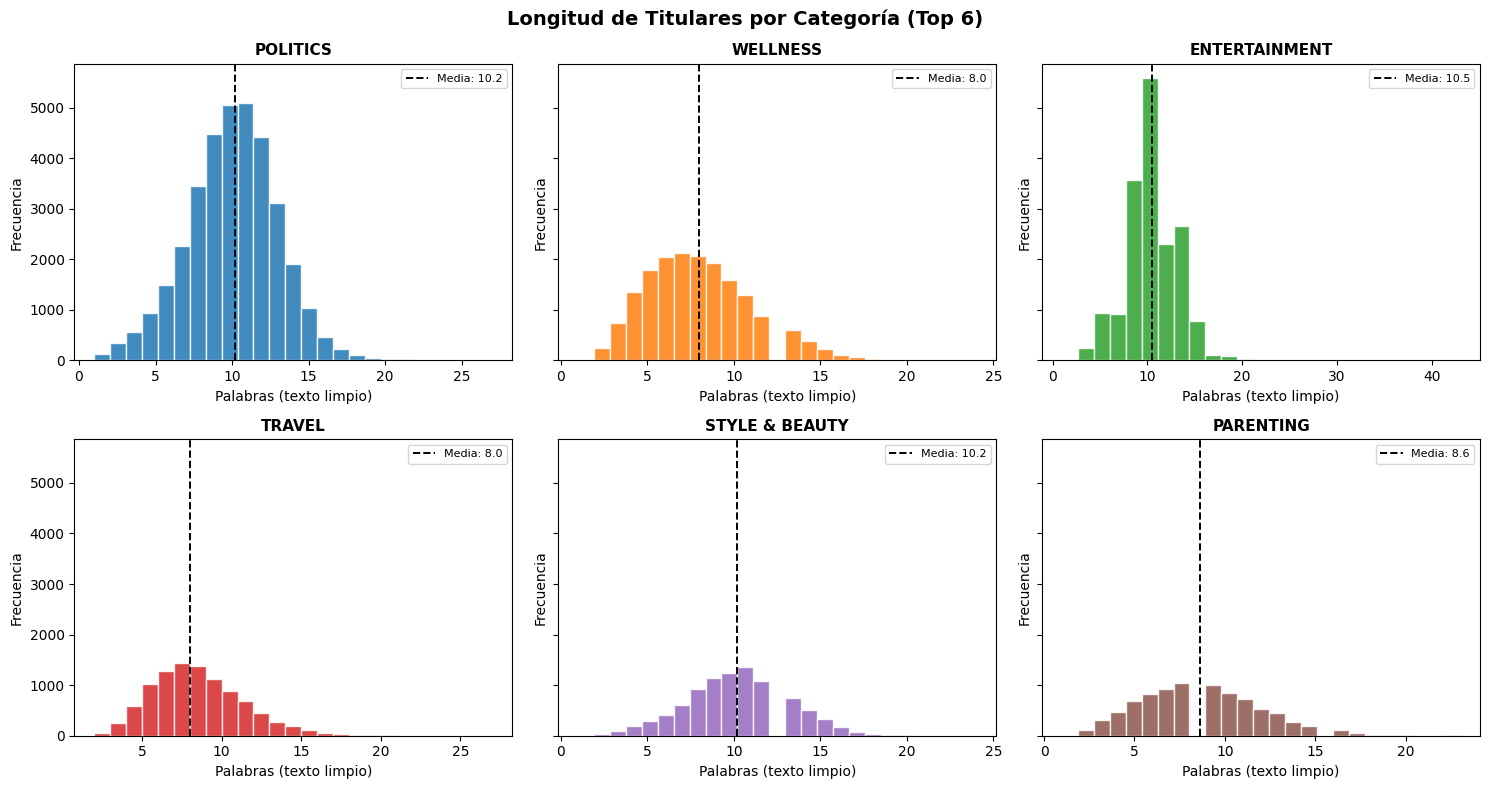

In [14]:

# ── Calcular longitud en palabras ────────────────────────────
df['longitud_original'] = df[COLUMNA_TEXTO].apply(
    lambda x: len(str(x).split()) if isinstance(x, str) else 0
)
df['longitud_limpio'] = df[COLUMNA_TEXTO].apply(
    lambda x: len(str(x).split()) if isinstance(x, str) else 0
)



# ── Histograma por categoría (top 6) ─────────────────────────
top6_cats = df[COLUMNA_OBJETIVO].value_counts().head(6).index.tolist()
df_top6   = df[df[COLUMNA_OBJETIVO].isin(top6_cats)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
fig.suptitle(
    'Longitud de Titulares por Categoría (Top 6)',
    fontsize=14, fontweight='bold'
)

colores = sns.color_palette('tab10', 6)

for ax, cat, color in zip(axes.flatten(), top6_cats, colores):
    datos = df_top6[df_top6[COLUMNA_OBJETIVO] == cat]['longitud_limpio']
    ax.hist(datos, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(datos.mean(), color='black', linestyle='--',
               linewidth=1.4, label=f"Media: {datos.mean():.1f}")
    ax.set_title(cat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Palabras (texto limpio)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Conclusiones:** 
- Las medias son muy similares entre categorías (8.0 – 10.5), por lo que la longitud sola no es un buen discriminador entre categorías.
- ENTERTAINMENT es la excepción: su cola larga podría añadir ruido al modelo si no se filtran outliers extremos (titulares > 25 palabras).

#### 2.2.5 Gráfica 5:  WordCloud de palabras por categoría 

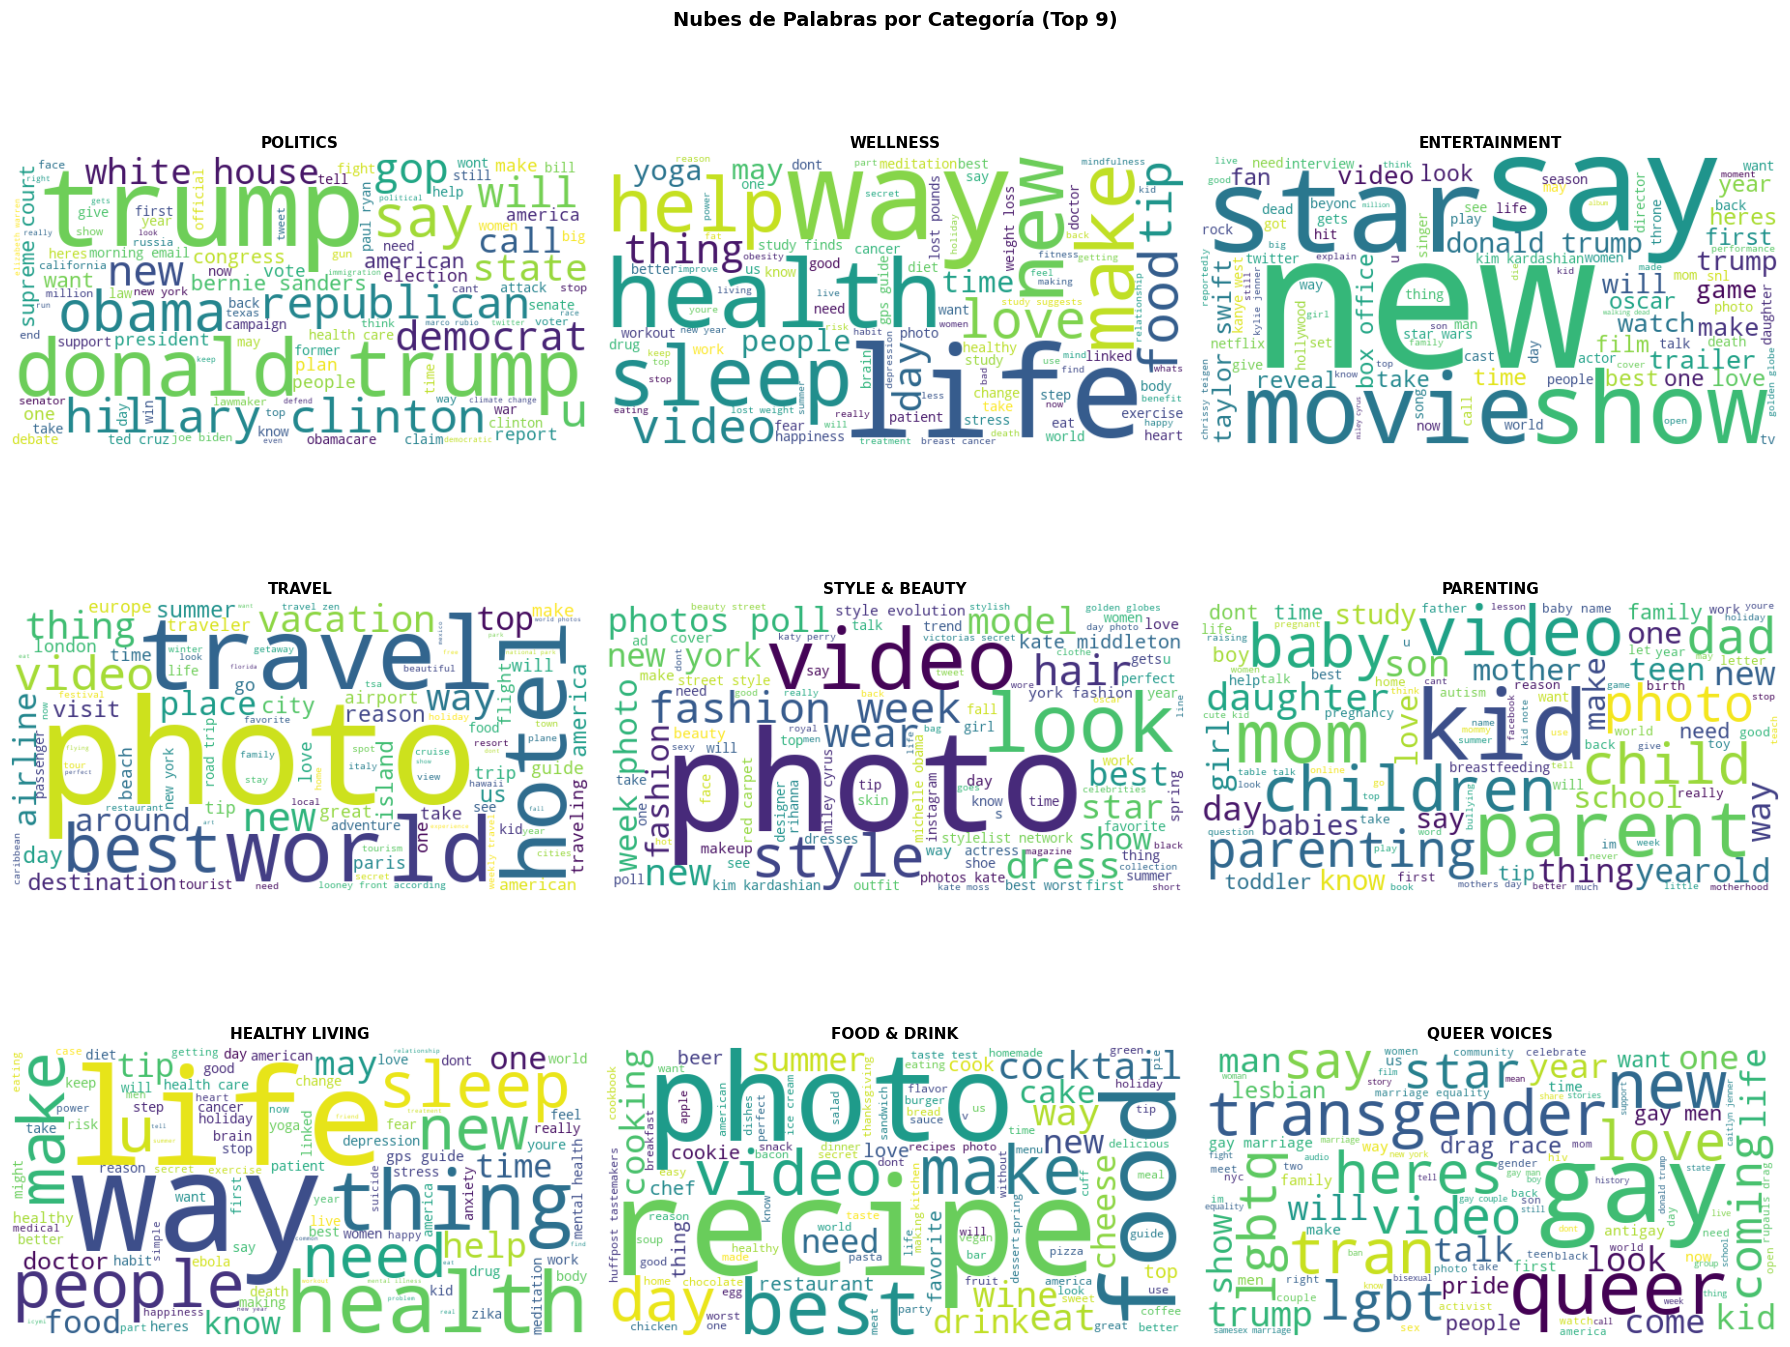

In [15]:
top9_cats = df[COLUMNA_OBJETIVO].value_counts().head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Nubes de Palabras por Categoría (Top 9)', fontsize=14, fontweight='bold')

for ax, categoria in zip(axes.flatten(), top9_cats):
    # Concatenar todos los textos de la categoría
    if 'texto_procesado' in df.columns:
        textos_cat = ' '.join(
            df.loc[df[COLUMNA_OBJETIVO] == categoria, 'texto_procesado']
              .dropna().astype(str).values
        )
    else:
        textos_cat = ' '.join(
            df.loc[df[COLUMNA_OBJETIVO] == categoria, COLUMNA_TEXTO]
              .dropna().astype(str).values
        )
    
    # Generar WordCloud
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(textos_cat)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(categoria, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3.Preparación de datos 

En este apartado se describe y aplica las estrategias de preparación de datos utilizadas para el problema de clasificación de titulares de noticias por categoría. Cada decisión está fundamentada en los hallazgos de la inspección del dataset realizada anteriormente.



#### **Resumen de estrategias aplicadas**

| # | Estrategia | Justificación (inspección) |
|---|------------|---------------------------|
| 1 | Eliminación de nulos en columna de texto | Se detectaron NaN que romperían la vectorización|
| 2 | Fusión de categorías cuasi-idénticas | La matriz de similitud coseno reveló pares con similitud 0.97: `PARENTING/PARENTS` y `WELLNESS/HEALTHY LIVING` son indistinguibles |
| 3 | Conversión de variables (Label Encoding) | La columna `category` es categórica y debe ser numérica para los modelos |
| 4 | Preprocesamiento NLP del texto | Los titulares contienen stopwords, puntuación y formas flexionadas que añaden ruido |
| 5 | Balanceo del dataset | La distribución de clases mostró desbalance significativo entre categorías |
| 6 | Vectorización TF-IDF | Convierte el texto limpio en representación numérica densa y ponderada |


### 3.1 Manejo de valores faltantes

**Hallazgo en la inspección:** `df.isnull().sum()` reveló que la columna `clean_description` puede contener `NaN`. Un valor nulo en el texto de entrada rompe la vectorización y el tokenizado, ya que las funciones de texto esperan cadenas.

**Estrategia aplicada:** Eliminación de filas con texto nulo. No se realiza imputación porque un titular vacío no aporta información semántica válida; rellenarlo con un placeholder (`"unknown"`) introduciría ruido artificial.

In [16]:
# ── 1. Manejo de valores nulos ────────────────────────────────────────────

nulos_antes = df[COLUMNA_NULL].isnull().sum()
print(f"Filas con texto nulo ANTES: {nulos_antes}")

# Eliminar filas donde el texto sea NaN o cadena vacía
df = df[df[COLUMNA_NULL].notna()].copy()
df = df[df[COLUMNA_NULL].str.strip() != ''].copy()
df.reset_index(drop=True, inplace=True)

nulos_despues = df[COLUMNA_NULL].isnull().sum()
print(f"Filas con texto nulo DESPUÉS: {nulos_despues}")
print(f"Registros restantes: {df.shape[0]:,}")

Filas con texto nulo ANTES: 19784
Filas con texto nulo DESPUÉS: 0
Registros restantes: 186,857


### 3.2 Fusión de categorías cuasi-idénticas

**Hallazgo en la inspección:** La matriz de similitud coseno entre vectores TF-IDF por categoría reveló múltiples pares con similitudes críticas (desde **0.71 hasta 0.97**), lo que indica que son prácticamente indistinguibles a nivel léxico y comparten el mismo universo de vocabulario:


**Estrategia aplicada:** Fusión de etiquetas en la columna `category` **antes** de realizar el preprocesamiento NLP y el Label Encoding. Se eligió el nombre más representativo o genérico de cada grupo como etiqueta canónica para consolidar el corpus.

Clases ANTES de fusión : 42
Clases DESPUÉS de fusión: 30
Categorías eliminadas   : 12

Tamaño de las categorías resultantes de la fusión:
  · WORLD NEWS           → 8,148 registros
  · ENVIRONMENT          → 3,402 registros
  · FOOD & DRINK         → 8,222 registros
  · EDUCATION            → 1,815 registros
  · PARENTING            → 12,104 registros
  · IMPACT               → 3,058 registros
  · WELLNESS             → 26,864 registros
  · ARTS & CULTURE       → 3,215 registros
  · STYLE & BEAUTY       → 10,789 registros
Categorías en la visualización: 30


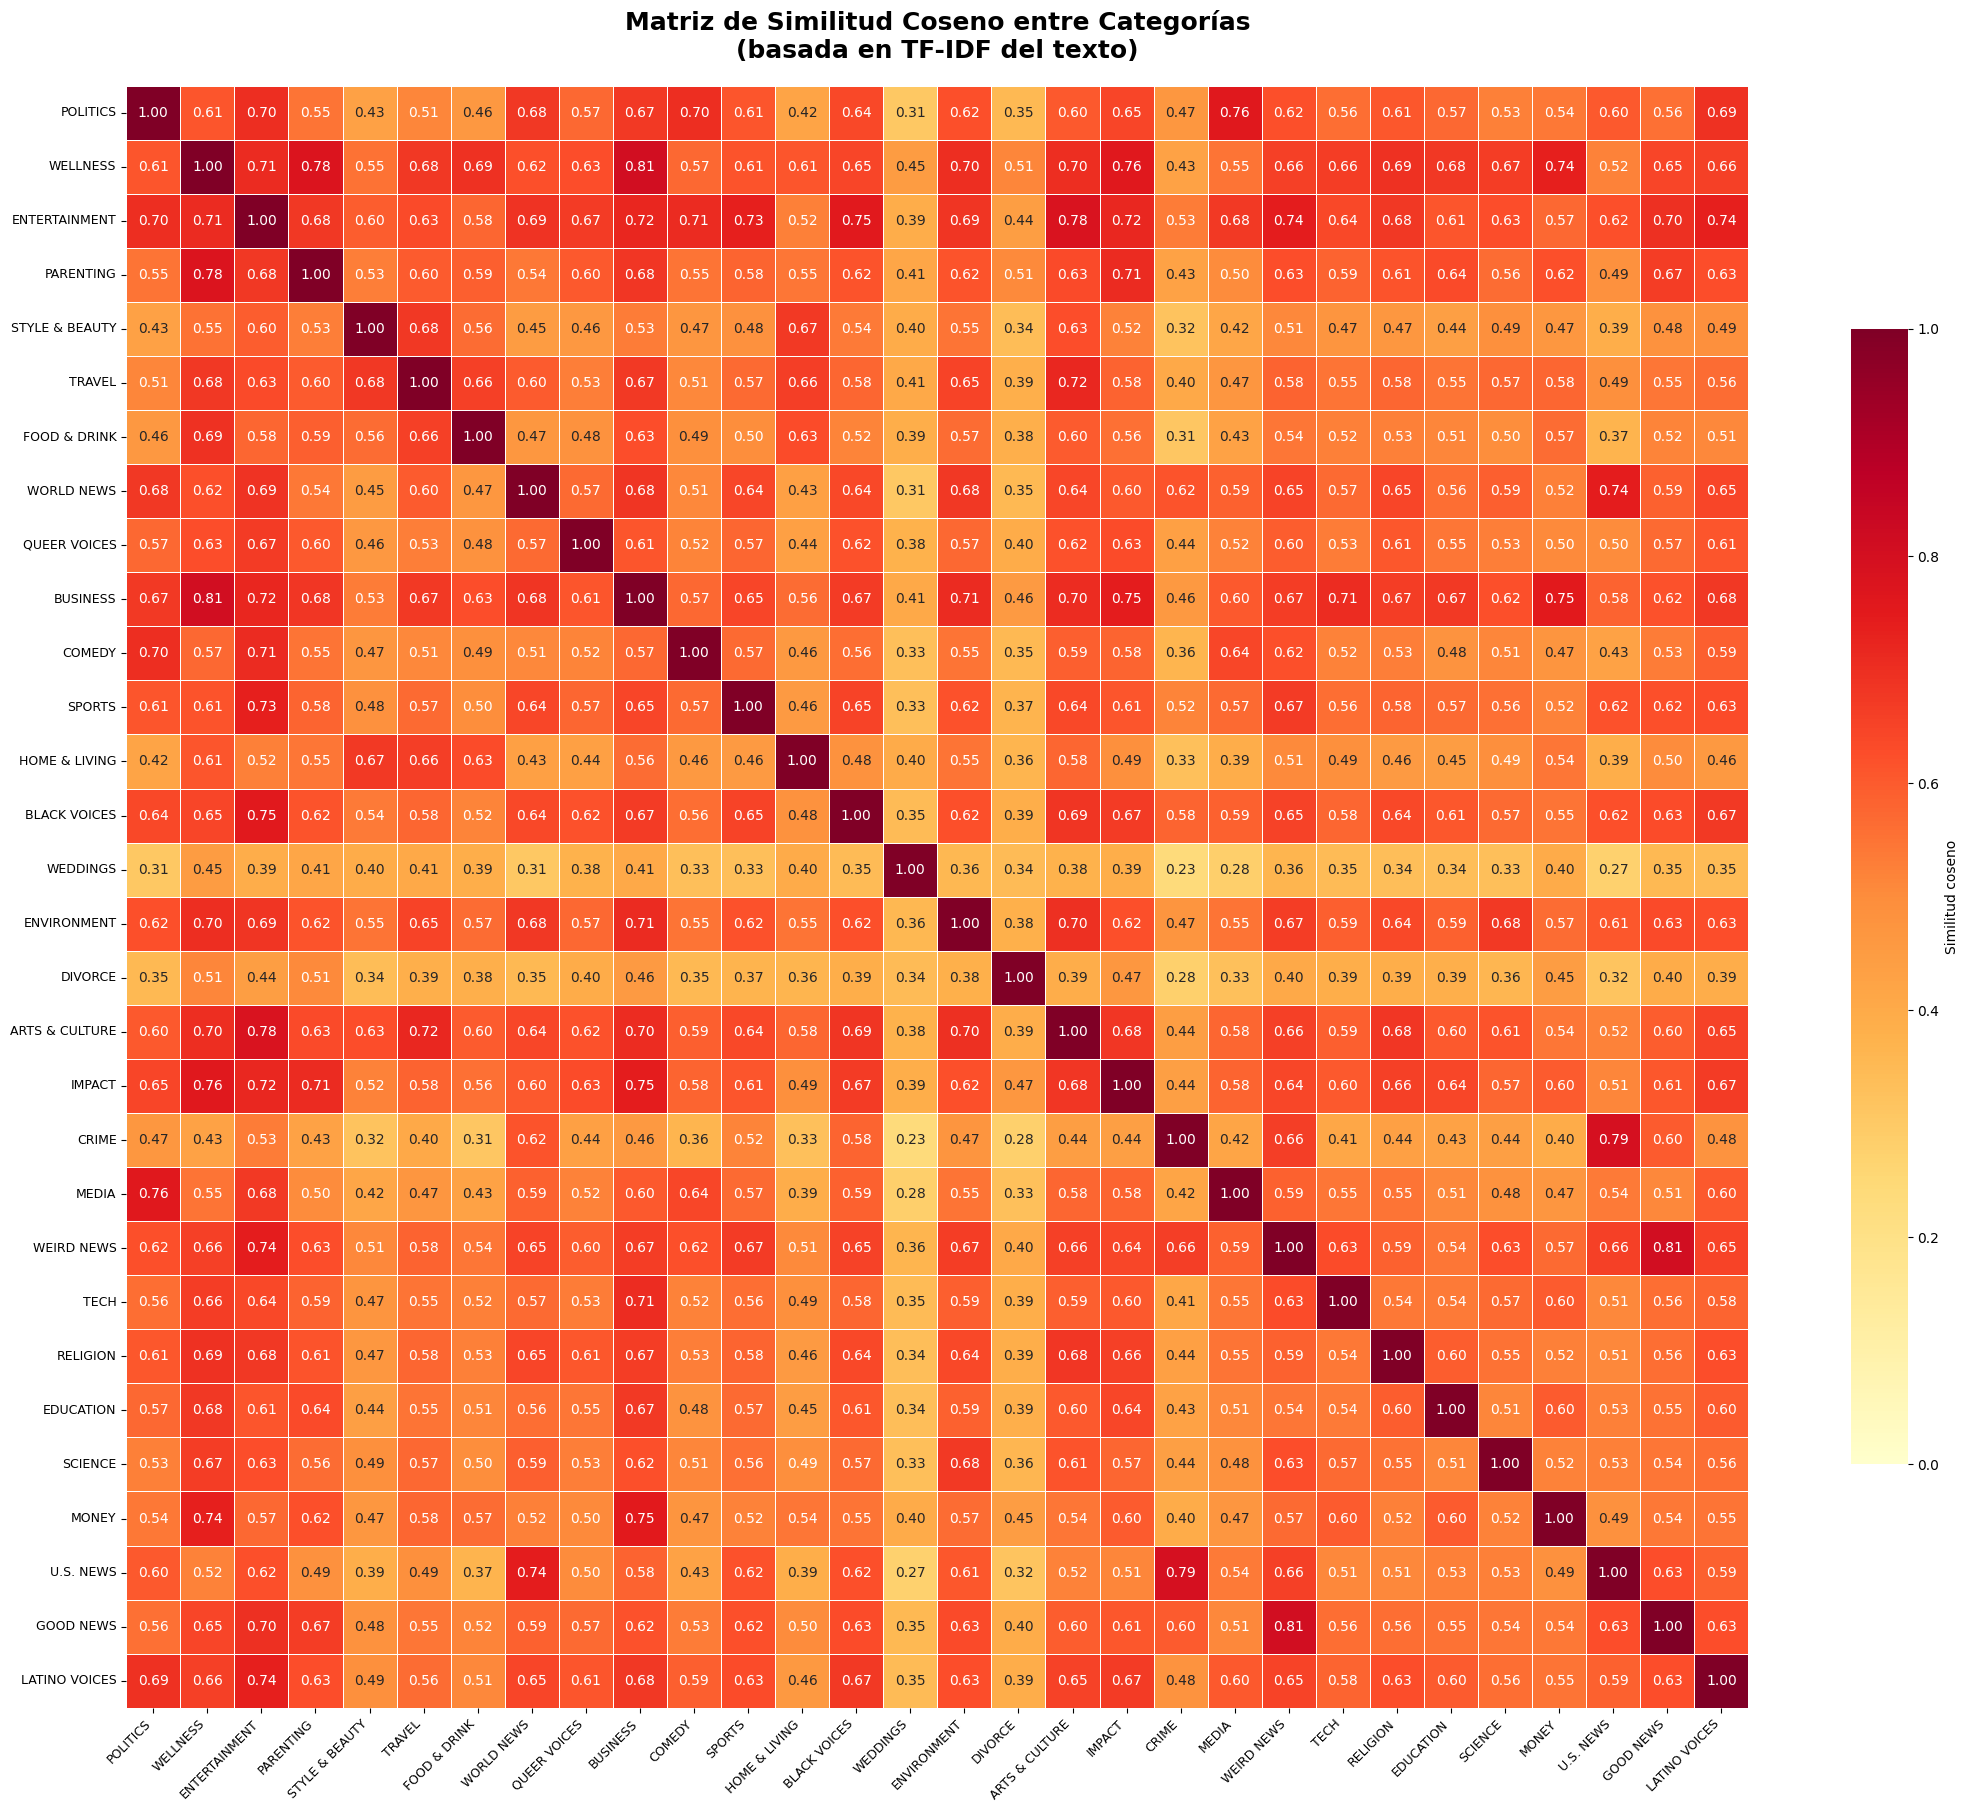

In [17]:


# Mapa: etiqueta original → etiqueta canónica
FUSIONES = {
    'PARENTS':        'PARENTING',
    'HEALTHY LIVING': 'WELLNESS',
    'THE WORLDPOST':  'WORLD NEWS',
    'TASTE':          'FOOD & DRINK',
    'ARTS':           'ARTS & CULTURE',
    'STYLE':          'STYLE & BEAUTY',
    'GREEN':          'ENVIRONMENT',       # similitud ~0.85
    'CULTURE & ARTS': 'ARTS & CULTURE',    # duplicado semántico
    'FIFTY':          'WELLNESS',          # subconjunto de salud/vida
    
    # — Fusiones nuevas (ecomendadas) —
    'WORLDPOST':      'WORLD NEWS',        # residuo de fusión anterior
    'COLLEGE':        'EDUCATION',         # subconjunto educativo
    'WOMEN':          'IMPACT',
    'IMPACT':         'WELLNESS'
}

clases_antes = df[COLUMNA_OBJETIVO].nunique()
conteo_antes_fusion = df[COLUMNA_OBJETIVO].value_counts()

# Aplicar el mapeo (las categorías no listadas quedan sin cambio)
df[COLUMNA_OBJETIVO] = df[COLUMNA_OBJETIVO].replace(FUSIONES)

clases_despues = df[COLUMNA_OBJETIVO].nunique()

print(f"Clases ANTES de fusión : {clases_antes}")
print(f"Clases DESPUÉS de fusión: {clases_despues}")
print(f"Categorías eliminadas   : {clases_antes - clases_despues}")
print()

# Verificación: mostrar el nuevo tamaño de las categorías fusionadas
cats_fusionadas = list(set(FUSIONES.values()))
print("Tamaño de las categorías resultantes de la fusión:")
for cat in cats_fusionadas:
    n = (df[COLUMNA_OBJETIVO] == cat).sum()
    print(f"  · {cat:<20} → {n:,} registros")



# ── Parámetros generales 

TOP_CATEGORIAS = df[COLUMNA_OBJETIVO].nunique()   
TOP_PALABRAS   = 20

# Filtrar las TOP_CATEGORIAS más frecuentes
cats_top = df[COLUMNA_OBJETIVO].value_counts().head(TOP_CATEGORIAS).index.tolist()
df_top   = df[df[COLUMNA_OBJETIVO].isin(cats_top)].copy()

print(f"Categorías en la visualización: {len(cats_top)}")  

tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vec.fit_transform(df_top[COLUMNA_TEXTO])

# ── Promedio de vectores TF-IDF por categoría
category_vectors = {}
for cat in cats_top:
    mask = df_top[COLUMNA_OBJETIVO] == cat
    cat_matrix = X_tfidf[mask.values]
    category_vectors[cat] = np.asarray(cat_matrix.mean(axis=0)).flatten()

# Matriz de similitud coseno entre categorías
cat_names  = list(category_vectors.keys())
cat_matrix = np.vstack(list(category_vectors.values()))
sim_matrix = cosine_similarity(cat_matrix)
sim_df = pd.DataFrame(sim_matrix, index=cat_names, columns=cat_names)

# ── Graficar 
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    sim_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",          
    vmin=0, vmax=1,         
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Similitud coseno", "shrink": 0.7},
    ax=ax
)
ax.set_title(
    "Matriz de Similitud Coseno entre Categorías\n(basada en TF-IDF del texto)",
    fontsize=18, fontweight="bold", pad=20
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


### 3.3 Conversión de variables (Label Encoding)

**Hallazgo en la inspección:** La columna `category` es de tipo `object` (cadena). Los algoritmos de machine learning requieren entradas numéricas.

**Estrategia aplicada:** `LabelEncoder` de scikit-learn asigna un entero único a cada categoría. Se conserva también la columna original para interpretabilidad. Se guarda el encoder para poder recuperar los nombres de clase durante la evaluación del modelo. Al ejecutarse **después de la fusión**, el encoder ya trabaja con el conjunto de clases definitivo y no habrá códigos huérfanos.

In [18]:
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df[COLUMNA_OBJETIVO])

mapeo = pd.DataFrame({
    'Categoría': le.classes_,
    'Código':    le.transform(le.classes_)
}).sort_values('Código').reset_index(drop=True)

print(f"Total de clases únicas: {len(le.classes_)}")
display(mapeo.style
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#4472C4'), ('color', 'white'),
                  ('font-weight', 'bold'), ('padding', '8px')]
    }])
    .background_gradient(subset=['Código'], cmap='Blues')
)

Total de clases únicas: 30


,Categoría,Código
0,ARTS & CULTURE,0
1,BLACK VOICES,1
2,BUSINESS,2
3,COMEDY,3
4,CRIME,4
5,DIVORCE,5
6,EDUCATION,6
7,ENTERTAINMENT,7
8,ENVIRONMENT,8
9,FOOD & DRINK,9


### 3.4 Preprocesamiento NLP del texto

**Hallazgo en la inspección:** La columna `clean_description` ya pasó por una limpieza básica. Sin embargo, el análisis de longitud de titulares y la inspección visual del corpus mostraron la presencia de:
- Stopwords en inglés (`the`, `a`, `of`) que no discriminan categorías.
- Formas flexionadas (`running`, `ran`, `runs`) que fragmentan el vocabulario sin añadir semántica diferencial.
- Signos de puntuación residuales y dígitos aislados.

**Estrategia aplicada:** Pipeline NLP con tres pasos en orden:
1. **Minúsculas + eliminación de puntuación y números** 
2. **Tokenización** 
3. **Eliminación de stopwords** 
4. **Lematización** (`WordNetLemmatizer`) 

In [19]:

# ── Stopwords
STOP_WORDS = set(stopwords.words('english'))

STOP_WORDS_EXTRA = {
    # Verbos comunes que lematizan a formas no cubiertas
    'says', 'said', 'saying',
    'makes', 'made', 'making',
    'gets', 'got', 'getting',
    'goes', 'went', 'going',
    'comes', 'came', 'coming',
    'takes', 'took', 'taking',
    'knows', 'knew', 'knowing',
    'thinks', 'thought', 'thinking',
    'wants', 'wanted', 'wanting',
    'looks', 'looked', 'looking',
    'shows', 'showed', 'showing',
    # Formas lematizadas que igual son ruido
    'say', 'make', 'get', 'go', 'come',
    'take', 'know', 'think', 'want',
    'look', 'show', 'give', 'use',
    'way', 'new', 'best', 'good',
    'like', 'also', 'one', 'two',
    'year', 'day', 'time', 'people',
    'photo', 'video', 'watch',   
    'thing', 'need', 'find',     
    'life', 'man', 'home',
    'first', 'top', 'big',
    'talk', 'tell', 'dont',
    'back', 'well', 'still',

    'trump', 'donald', 
    
    'yearold', 'week', 'day', 'wont', 'could'

}
STOP_WORDS_EXTRA.add('imageblog')

STOP_WORDS = STOP_WORDS | STOP_WORDS_EXTRA

lemmatizer = WordNetLemmatizer()

from nltk import pos_tag
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag: str) -> str:
    """Convierte POS tag de Treebank a formato WordNet."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # default

def preprocesar_texto(texto: str) -> str:

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Eliminar URLs (nuevo — antes no se eliminaban)
    texto = re.sub(r'http\S+|www\S+', '', texto)

    # 3. Eliminar dígitos y puntuación
    texto = re.sub(r'\d+', '', texto)
    texto = texto.translate(str.maketrans('', '', string.punctuation))

    # 4. Tokenizar
    tokens = word_tokenize(texto)

    # 5. Primera eliminación de stopwords (formas originales)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # 6. Lematizar CON POS tag correcto (verbo, sustantivo, adjetivo)
    pos_tags = pos_tag(tokens)
    tokens = [
        lemmatizer.lemmatize(token, get_wordnet_pos(pos))
        for token, pos in pos_tags
    ]

    # 7.Segunda eliminación DESPUÉS de lematizar (captura formas residuales)
    #    Aquí se eliminan: "says"→"say", "makes"→"make", etc.
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    return ' '.join(tokens)

# ── Aplicar al DataFrame ───────────────────────────────────────────────────
df['texto_procesado'] = df[COLUMNA_TEXTO].apply(preprocesar_texto)

# ── Verificación robusta ───────────────────────────────────────────────────
print("=" * 60)
print("VERIFICACIÓN DE STOPWORDS RESIDUALES")
print("=" * 60)

# 1. Comparación antes/después
print("\nEjemplos de transformación:")
comparacion = pd.DataFrame({
    'Original' : df[COLUMNA_TEXTO].head(5).values,
    'Procesado': df['texto_procesado'].head(5).values
})
display(comparacion)

# 2. Vocabulario
vocab_original  = set(' '.join(df[COLUMNA_TEXTO].astype(str)).split())
vocab_procesado = set(' '.join(df['texto_procesado']).split())
print(f"\nVocabulario original : {len(vocab_original):,} tokens únicos")
print(f"Vocabulario procesado: {len(vocab_procesado):,} tokens únicos")
print(f"Reducción            : {(1 - len(vocab_procesado)/len(vocab_original))*100:.1f}%")





VERIFICACIÓN DE STOPWORDS RESIDUALES

Ejemplos de transformación:


,Original,Procesado
0,over million americans roll up sleeves for omi...,million american roll sleeve omicrontargeted c...
1,american airlines flyer charged banned for lif...,american airline flyer charge ban punch flight...
2,of the funniest tweets about cats and dogs thi...,funny tweet cat dog sept
3,the funniest tweets from parents this week sept,funny tweet parent sept
4,woman who called cops on black birdwatcher los...,woman call cop black birdwatcher lose lawsuit ...



Vocabulario original : 64,131 tokens únicos
Vocabulario procesado: 54,846 tokens únicos
Reducción            : 14.5%



### 3.5 Balanceo del conjunto de datos

**Hallazgo en la inspección:** El gráfico de distribución de categorías mostró una disparidad marcada entre clases. Las categorías más frecuentes (como `POLITICS` o `WELLNESS`) tienen órdenes de magnitud más ejemplos que las minoritarias. Este desbalance hace que los clasificadores tiendan a predecir siempre la clase mayoritaria, inflando métricas globales y degradando el recall en clases pequeñas.

**Estrategia aplicada:** *Undersampling* aleatorio estratificado. Se define un techo máximo de registros por clase (`MAX_POR_CLASE`). Clases con más muestras se reducen aleatoriamente al umbral; clases por debajo del umbral se conservan completas. Esta estrategia:
- Reduce el tiempo de entrenamiento.
- Previene el sesgo hacia clases mayoritarias.
- Es preferible al oversampling sintético (SMOTE) para texto, pues SMOTE en espacio TF-IDF genera vectores poco realistas.

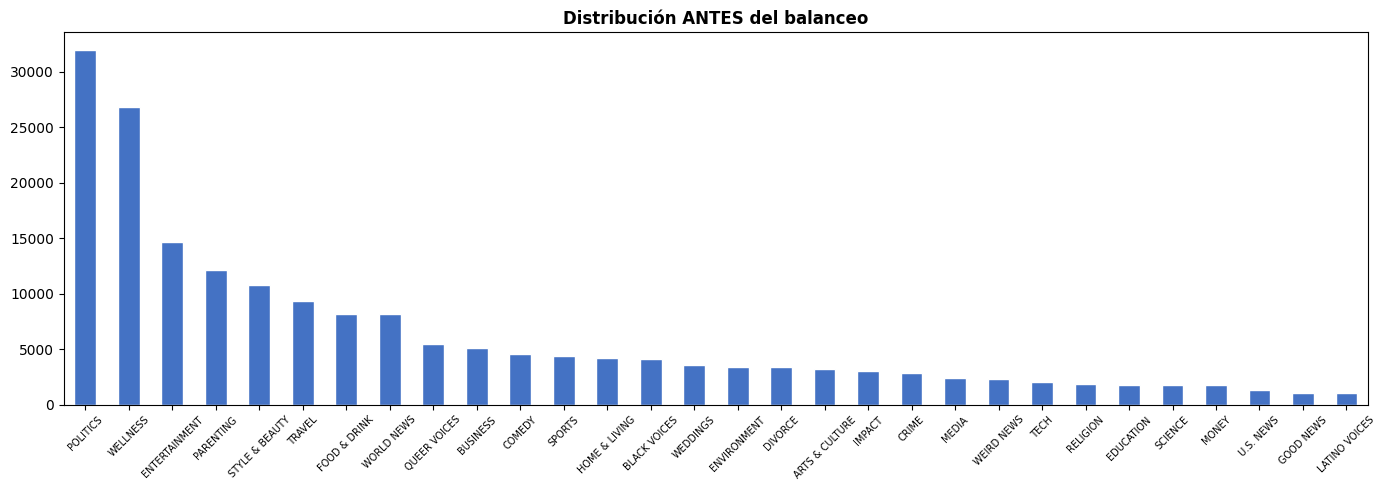

Registros antes del balanceo: 186,857


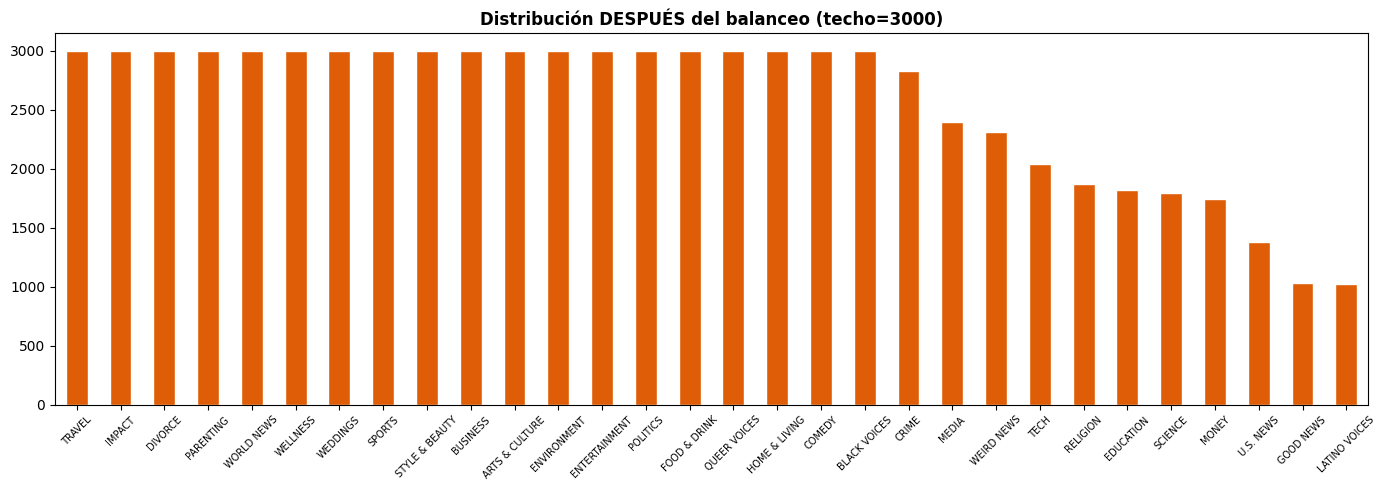

Registros después del balanceo: 77,215


In [20]:
# ── 4. Balanceo del dataset (Undersampling) ───────────────────────────────

conteo_antes = df[COLUMNA_OBJETIVO].value_counts()

MAX_POR_CLASE = 3000

partes = []
for categoria in df[COLUMNA_OBJETIVO].unique():
    subset = df[df[COLUMNA_OBJETIVO] == categoria]
    if len(subset) > MAX_POR_CLASE:
        subset = resample(subset, replace=False, n_samples=MAX_POR_CLASE, random_state=42)
    partes.append(subset)

df_bal = pd.concat(partes).sample(frac=1, random_state=42).reset_index(drop=True)
conteo_despues = df_bal[COLUMNA_OBJETIVO].value_counts()

# Gráfica ANTES
fig, ax = plt.subplots(figsize=(14, 5))
conteo_antes.plot(kind='bar', ax=ax, color='#4472C4', edgecolor='white')
ax.set_title('Distribución ANTES del balanceo', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Registros antes del balanceo: {len(df):,}")

# Gráfica DESPUÉS
fig, ax = plt.subplots(figsize=(14, 5))
conteo_despues.plot(kind='bar', ax=ax, color="#DE5D06", edgecolor='white')
ax.set_title(f'Distribución DESPUÉS del balanceo (techo={MAX_POR_CLASE})', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Registros después del balanceo: {len(df_bal):,}")

**Análisis:** El **Undersampling** aplicado recortó exitosamente las clases que superaban el umbral de 3,000 registros. Sin embargo, las clases que ya estaban por debajo de ese umbral no pueden ser afectadas por esta técnica, ya que no hay registros que eliminar.

**Estrategia aplicada:**
Aplicar **Oversampling**, debido a que es necesario para resolver el problema de las clases con déficit de datos. Juntas, estas dos técnicas producen un dataset completamente balanceado, listo para entrenar un modelo de clasificación robusto y equitativo para todas las categorías del dataset de noticias.

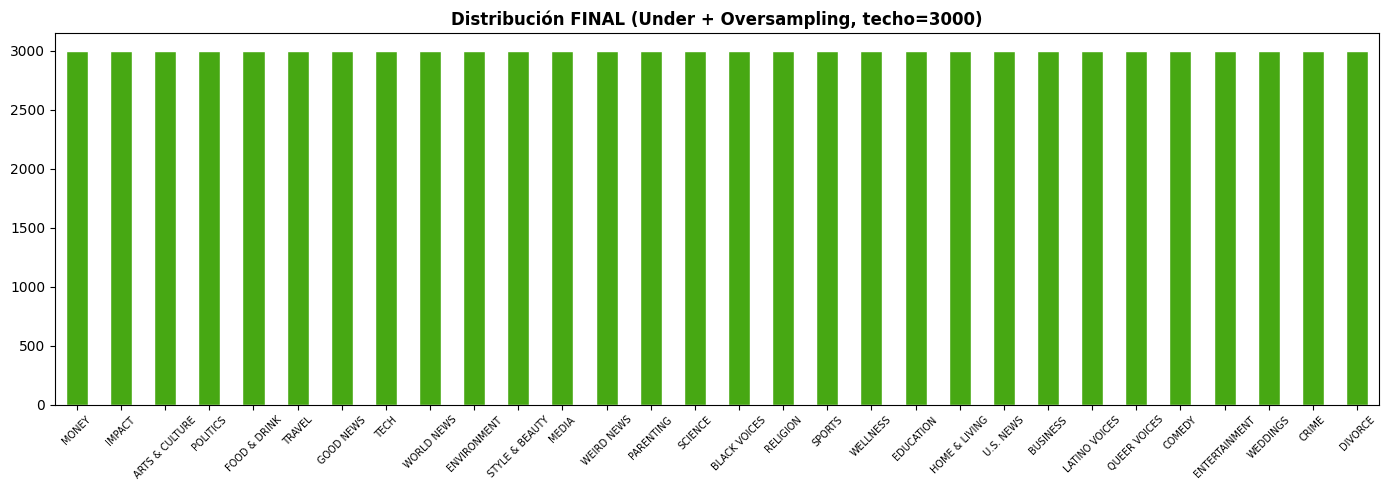

Registros después del oversampling:  90,000


In [21]:
# Oversampling 

MIN_POR_CLASE = 3000 

partes_over = []
for categoria in df_bal[COLUMNA_OBJETIVO].unique():
    subset = df_bal[df_bal[COLUMNA_OBJETIVO] == categoria]
    if len(subset) < MIN_POR_CLASE:
        subset = resample(
            subset,
            replace=True,
            n_samples=MIN_POR_CLASE,
            random_state=42
        )
    partes_over.append(subset)

df_final = pd.concat(partes_over).sample(frac=1, random_state=42).reset_index(drop=True)

conteo_final = df_final[COLUMNA_OBJETIVO].value_counts()

# Gráfica FINAL
fig, ax = plt.subplots(figsize=(14, 5))
conteo_final.plot(kind='bar', ax=ax, color="#47A813", edgecolor='white')
ax.set_title(f'Distribución FINAL (Under + Oversampling, techo={MIN_POR_CLASE})', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Registros después del oversampling:  {len(df_final):,}")


**Análisis:** Al aplicar Oversampling, cada fila real se repetirá en promedio ~3.6 veces. Esto puede causar sobreajuste, ya que el modelo verá las mismas frases repetidas muchas veces durante el entrenamiento. Sin embargo, es un riesgo asumido y necesario para garantizar que el dataset quede completamente balanceado, priorizando que el modelo tenga igual representación de todas las categorías sobre la variedad de los datos en las clases minoritarias.

### 3.6 Vectorización del texto (TF-IDF)

**Hallazgo en la inspección:** El texto preprocesado es texto libre. Los modelos de machine learning que implementaremos (regresión multivariada, árboles de decisión, random forest, y redes neuronales (MLP, y DNN) requieren vectores numéricos de longitud fija.

**Estrategia aplicada:** **TF-IDF** (*Term Frequency – Inverse Document Frequency*) con unigramas y bigramas (`ngram_range=(1,2)`).

- **TF** pondera las palabras frecuentes *dentro* de una misma categoria.
- **IDF** penaliza palabras que aparecen en muchos documentos (término poco discriminativo).
- Los **bigramas** capturan colocaciones relevantes que los unigramas pierden.
- `max_features=10_000` limita el vocabulario inicial. El filtrado fino se realizará en el paso 6 con Chi-cuadrado.


In [22]:
# ── 6. Vectorización TF-IDF ────────────────────────────────────────────────



tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),      # unigramas y bigramas
    min_df=3,                # ignorar términos que aparecen en < 3 documentos
    max_df=0.70,             # ignorar términos presentes en > 70 % de los docs
    sublinear_tf=True,       # aplica log(1+TF) para suavizar frecuencias altas
    strip_accents='unicode'
)

X_tfidf = tfidf.fit_transform(df_final['texto_procesado'])
y        = le.transform(df_final[COLUMNA_OBJETIVO])

print(f"Dimensión de la matriz TF-IDF : {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]:,} documentos × {X_tfidf.shape[1]:,} características")
print(f"Densidad de la matriz          : {X_tfidf.nnz / (X_tfidf.shape[0]*X_tfidf.shape[1]):.4%}")

# Top-15 términos con mayor TF-IDF promedio en todo el corpus
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
feat_names = tfidf.get_feature_names_out()
top_idx    = mean_tfidf.argsort()[-15:][::-1]

print("\nTop 15 términos por TF-IDF promedio:")
for rk, idx in enumerate(top_idx, 1):
    print(f"  {rk:2}. {feat_names[idx]:<30} {mean_tfidf[idx]:.4f}")

Dimensión de la matriz TF-IDF : (90000, 30000)
  → 90,000 documentos × 30,000 características
Densidad de la matriz          : 0.0226%

Top 15 términos por TF-IDF promedio:
   1. woman                          0.0063
   2. divorce                        0.0048
   3. love                           0.0044
   4. world                          0.0043
   5. kid                            0.0039
   6. black                          0.0035
   7. school                         0.0033
   8. help                           0.0032
   9. change                         0.0031
  10. wed                            0.0031
  11. american                       0.0031
  12. marriage                       0.0029
  13. family                         0.0029
  14. child                          0.0028
  15. police                         0.0028


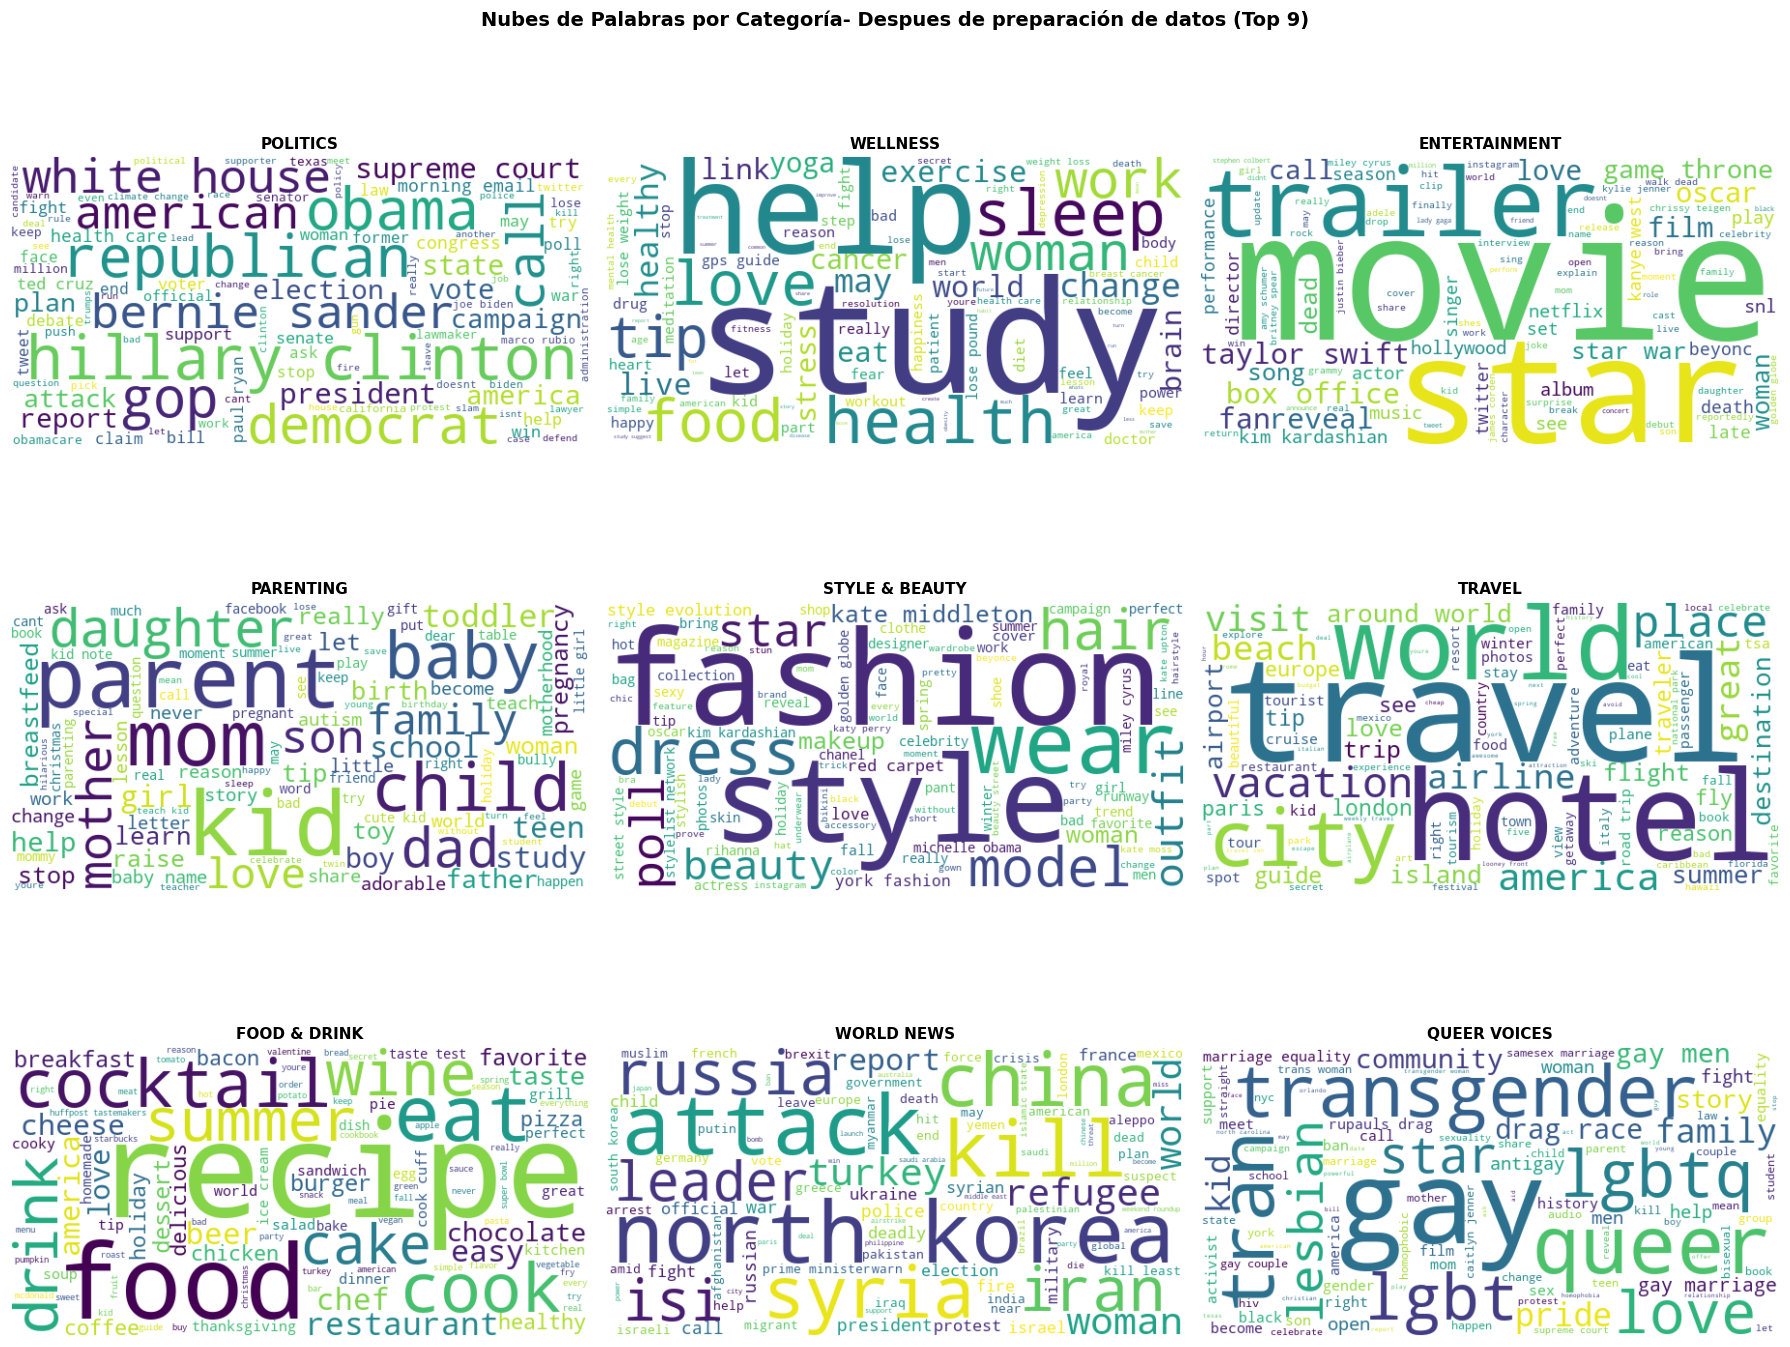

In [23]:
top9_cats = df[COLUMNA_OBJETIVO].value_counts().head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Nubes de Palabras por Categoría- Despues de preparación de datos (Top 9)', fontsize=14, fontweight='bold')

for ax, categoria in zip(axes.flatten(), top9_cats):
    # Concatenar todos los textos de la categoría
    if 'texto_procesado' in df.columns:
        textos_cat = ' '.join(
            df.loc[df[COLUMNA_OBJETIVO] == categoria, 'texto_procesado']
              .dropna().astype(str).values
        )
    else:
        textos_cat = ' '.join(
            df.loc[df[COLUMNA_OBJETIVO] == categoria, COLUMNA_TEXTO]
              .dropna().astype(str).values
        )
    
    # Generar WordCloud
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(textos_cat)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(categoria, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:

print("═" * 55)
print("  RESUMEN DEL PIPELINE DE PREPARACIÓN DE DATOS")
print("═" * 55)
print(f"  Registros finales          : {len(df_bal):>8,}")
print(f"  Clases únicas              : {len(le.classes_):>8}")
print(f"  Características TF-IDF     : {X_tfidf.shape[1]:>8,}")
#print(f"  Características tras Chi²  : {X_chi2.shape[1]:>8,}")
#print(f"  Reducción total vocabulario: {(1-X_chi2.shape[1]/X_tfidf.shape[1])*100:>7.1f}%")
print("─" * 55)

X = tfidf.transform(df_final['texto_procesado'])
#X = selector.transform(X)
y = df_final['category_enc'].values

print(f"Matriz final para entrenamiento : {X.shape}")
print(f"Etiquetas finales               : {y.shape}")
print(f"Clases únicas en y              : {len(set(y))}")


# ── 7. Exportar dataset limpio a CSV 
DATASET_EXPORTAR = df_final  
# ── Columnas a exportar ───────────────────────────────────────────────────
COLUMNAS_EXPORT = [
    COLUMNA_TEXTO,          # texto original
    'texto_procesado',      # texto limpio y lematizado
    COLUMNA_OBJETIVO,       # categoría (label legible)
    'category_enc'          # categoría codificada (entero)
]

columnas_validas = [c for c in COLUMNAS_EXPORT if c in DATASET_EXPORTAR.columns]
df_export = DATASET_EXPORTAR[columnas_validas].copy()

timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
nombre_csv  = f"dataset_limpio_{timestamp}.csv"
ruta_csv    = os.path.join(os.getcwd(), nombre_csv)   # misma carpeta del notebook

# ── Guardar 
df_export.to_csv(ruta_csv, index=False, encoding='utf-8-sig')  # utf-8-sig → compatible con Excel

# ── Confirmación
tamaño_mb = os.path.getsize(ruta_csv) / (1024 ** 2)



═══════════════════════════════════════════════════════
  RESUMEN DEL PIPELINE DE PREPARACIÓN DE DATOS
═══════════════════════════════════════════════════════
  Registros finales          :   77,215
  Clases únicas              :       30
  Características TF-IDF     :   30,000
───────────────────────────────────────────────────────
Matriz final para entrenamiento : (90000, 30000)
Etiquetas finales               : (90000,)
Clases únicas en y              : 30


In [25]:
# ── 8. División Train / Test ───────────────────────────────────────────────
# X ya contiene las 2,000 características seleccionadas por Chi²
# y contiene las 30 etiquetas codificadas

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 80% entrenamiento – 20% prueba
    random_state=42,
    stratify=y            # preserva la proporción de cada clase
)

print("═" * 50)
print("  PARTICIÓN TRAIN / TEST")
print("═" * 50)
print(f"  Total muestras   : {X.shape[0]:>10,}")
print(f"  Train            : {X_train.shape[0]:>10,}  ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"  Test             : {X_test.shape[0]:>10,}  ({X_test.shape[0]/X.shape[0]*100:.0f}%)")
print(f"  Características  : {X_train.shape[1]:>10,}"    )
print(f"  Clases           : {len(set(y_train)):>10}")
print("─" * 50)
print("Conjunto de entrenamiento y prueba listos.")

══════════════════════════════════════════════════
  PARTICIÓN TRAIN / TEST
══════════════════════════════════════════════════
  Total muestras   :     90,000
  Train            :     72,000  (80%)
  Test             :     18,000  (20%)
  Características  :     30,000
  Clases           :         30
──────────────────────────────────────────────────
Conjunto de entrenamiento y prueba listos.


---
## 4. Estrategia de Experimentación 


### 4.1 Ajuste de Hiperparámetros
Encontrar la combinación óptima de hiperparámetros para cada modelo que maximice
el desempeño en la clasificación de noticias en **30 categorías**.

### Metodología

Se aplica **`GridSearchCV`** con las siguientes configuraciones:

| Parámetro              | Valor              | Justificación                                               |
|------------------------|--------------------|-------------------------------------------------------------|
| Folds (cv)             | 5 (estratificado)  | Garantiza representación de las 30 clases en cada partición |
| Métrica de optimización| `scoring='accuracy`| Dado que el conjunto de datos se encuentra balanceado entre las 30 categorías, se emplea accuracy como métrica de optimización en el GridSearchCV |
| Refit                  | `True`             | Reentrena el mejor modelo sobre todo el train               |
| n_jobs                 | `-1`               | Paraleliza sobre todos los núcleos disponibles              |

### 4.2 Configuración global del experimento

In [26]:
# ── Configuración global del GridSearchCV
CV_FOLDS   = 5          
SCORING    = 'accuracy' 
N_JOBS     = -1         # IMPORTANTE: -1 para usar todos los núcleos de la CPU
VERBOSE    = 2   
RANDOM_STATE = 42

cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scaler = MaxAbsScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit SOLO sobre train
X_test_sc  = scaler.transform(X_test)        # mismo escalado para test

# Diccionario para guardar los resultados de todos los modelos
resultados = {}   # {nombre_modelo: {'best_params', 'best_cv_score', 'test_accuracy', 'report', 'cm', 'fit_time'}}

print("Configuración lista.")
print(f"  Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"  Estrategia CV: StratifiedKFold(n_splits={CV_FOLDS})")

Configuración lista.
  Train: (72000, 30000) | Test: (18000, 30000)
  Estrategia CV: StratifiedKFold(n_splits=5)


### 4.3 Función Auxiliar

In [27]:
# ── Función auxiliar: evaluar y guardar resultados
def evaluar_modelo(nombre, grid_search, X_te, y_te, label_encoder):

    best_model   = grid_search.best_estimator_
    y_pred       = best_model.predict(X_te)

    test_acc     = accuracy_score(y_te, y_pred)
    test_f1_mac  = f1_score(y_te, y_pred, average='macro')
    report       = classification_report(y_te, y_pred,
                                         target_names=label_encoder.classes_,
                                         zero_division=0)
    cm           = confusion_matrix(y_te, y_pred)

    resultados[nombre] = {
        'best_params'    : grid_search.best_params_,
        'best_cv_score'  : grid_search.best_score_,
        'test_accuracy'  : test_acc,
        'test_f1_macro'  : test_f1_mac,
        'report'         : report,
        'cm'             : cm,
        'fit_time_min'   : grid_search.refit_time_ / 60,
    }

    # ── Resumen en consola
    print("=" * 60)
    print(f"  RESULTADOS — {nombre}")
    print("=" * 60)
    print(f"  Mejores hiperparámetros : {grid_search.best_params_}")
    print(f"  Mejor accuracy (CV)     : {grid_search.best_score_:.4f}")
    print(f"  Accuracy en TEST        : {test_acc:.4f}")
    print(f"  F1-macro  en TEST       : {test_f1_mac:.4f}")
    print(f"  Tiempo de refit         : {grid_search.refit_time_:.1f} s")
    print()
    print(report)

    # ── Matriz de confusión
    fig, ax = plt.subplots(figsize=(18, 15))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    ax.set_title(f'Matriz de Confusión — {nombre}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()



### 4.4 MODELO 1 — REGRESIÓN LOGÍSTICA (Clasificación Multivariada)


#### Descripción General
**Regresión Logística** es un modelo estadístico lineal fundamentado en la teoría de probabilidades Bayesianas. Transforma combinaciones lineales de características mediante la función sigmoide para producir probabilidades entre 0 y 1, que luego se convierten en predicciones de clase mediante un umbral de decisión (típicamente 0.5).

Para problemas **multiclase** (como nuestro caso con 30 categorías), se extiende mediante el esquema **One-vs-Rest (OvR)** o **softmax multinomial**, donde:
- Se entrena un clasificador binario por cada clase contra todas las demás, o bien
- Se utiliza directamente la función softmax que genera probabilidades para todas las clases simultáneamente

#### Hiperparámetros Utilizados - experimento 1

| Hiperparámetro | Valor(es) Probado(s) | Rango Final |
|---|---|---|
| **C** (inverso de λ) | [0.1, 0.5, 1, 5, 10] | Elegido por GridSearchCV |
| **Penalty** | L2 | Fijo |
| **Class weight** | ['balanced', None] | Elegido por GridSearchCV |
| **Solver** | LBFGS | Fijo (L2 + mejor convergencia) |
| **Max iterations** | 1000 | Fijo |
| **Random state** | 42 | Fijo (reproducibilidad) |

In [26]:

param_grid_lr = {
    'C':           [0.1, 0.5, 1, 5, 10],  # Valores altos para forzar el ajuste fino, 
    'penalty': ['l2'],
    'class_weight': ['balanced', None]   ,     # Quitamos 'l1' para evitar el colapso de tiempo
}

lr_base = LogisticRegression(
    solver        = 'lbfgs',          
    max_iter      = 1000,
    tol           = 1e-4,
    random_state  = RANDOM_STATE,
    n_jobs        = 1
)
gs_lr = GridSearchCV(
    estimator  = lr_base,
    param_grid = param_grid_lr,
    cv         = cv_strategy,
    scoring    = SCORING,
    refit      = True,
    n_jobs     = N_JOBS,          
    verbose    = VERBOSE
)

# ── Resumen de combinaciones
n_combos = len(param_grid_lr['C']) * len(param_grid_lr['penalty'])
print(f"Combinaciones : {n_combos}  ×  {CV_FOLDS} folds  =  {n_combos * CV_FOLDS} ajustes")
print("Iniciando búsqueda …\n")

# Bloque de seguridad recomendado para Windows
if __name__ == '__main__':
    t0 = time.time()
    gs_lr.fit(X_train_sc, y_train)
    tiempo = time.time() - t0

    # ── Resultado del ajuste 
    print("\n" + "═" * 55)
    print("  RESULTADO DEL AJUSTE — Regresión Logística (saga)")
    print("═" * 55)
    print(f"  Mejor combinación   : {gs_lr.best_params_}")
    print(f"  Accuracy en CV      : {gs_lr.best_score_:.4f}")
    print(f"  Tiempo de búsqueda  : {tiempo / 60:.1f} min")
    print("─" * 55)

Combinaciones : 5  ×  5 folds  =  25 ajustes
Iniciando búsqueda …

Fitting 5 folds for each of 10 candidates, totalling 50 fits

═══════════════════════════════════════════════════════
  RESULTADO DEL AJUSTE — Regresión Logística (saga)
═══════════════════════════════════════════════════════
  Mejor combinación   : {'C': 5, 'class_weight': 'balanced', 'penalty': 'l2'}
  Accuracy en CV      : 0.6621
  Tiempo de búsqueda  : 10.8 min
───────────────────────────────────────────────────────


  RESULTADOS — Logistic Regression
  Mejores hiperparámetros : {'C': 5, 'class_weight': 'balanced', 'penalty': 'l2'}
  Mejor accuracy (CV)     : 0.6621
  Accuracy en TEST        : 0.6788
  F1-macro  en TEST       : 0.6775
  Tiempo de refit         : 26.7 s

                precision    recall  f1-score   support

ARTS & CULTURE       0.51      0.51      0.51       600
  BLACK VOICES       0.58      0.52      0.55       600
      BUSINESS       0.47      0.46      0.46       600
        COMEDY       0.56      0.51      0.53       600
         CRIME       0.75      0.78      0.76       600
       DIVORCE       0.77      0.70      0.73       600
     EDUCATION       0.77      0.83      0.80       600
 ENTERTAINMENT       0.48      0.49      0.49       600
   ENVIRONMENT       0.59      0.57      0.58       600
  FOOD & DRINK       0.72      0.73      0.72       600
     GOOD NEWS       0.89      0.94      0.91       600
 HOME & LIVING       0.67      0.66      0.66       600
        IMPAC

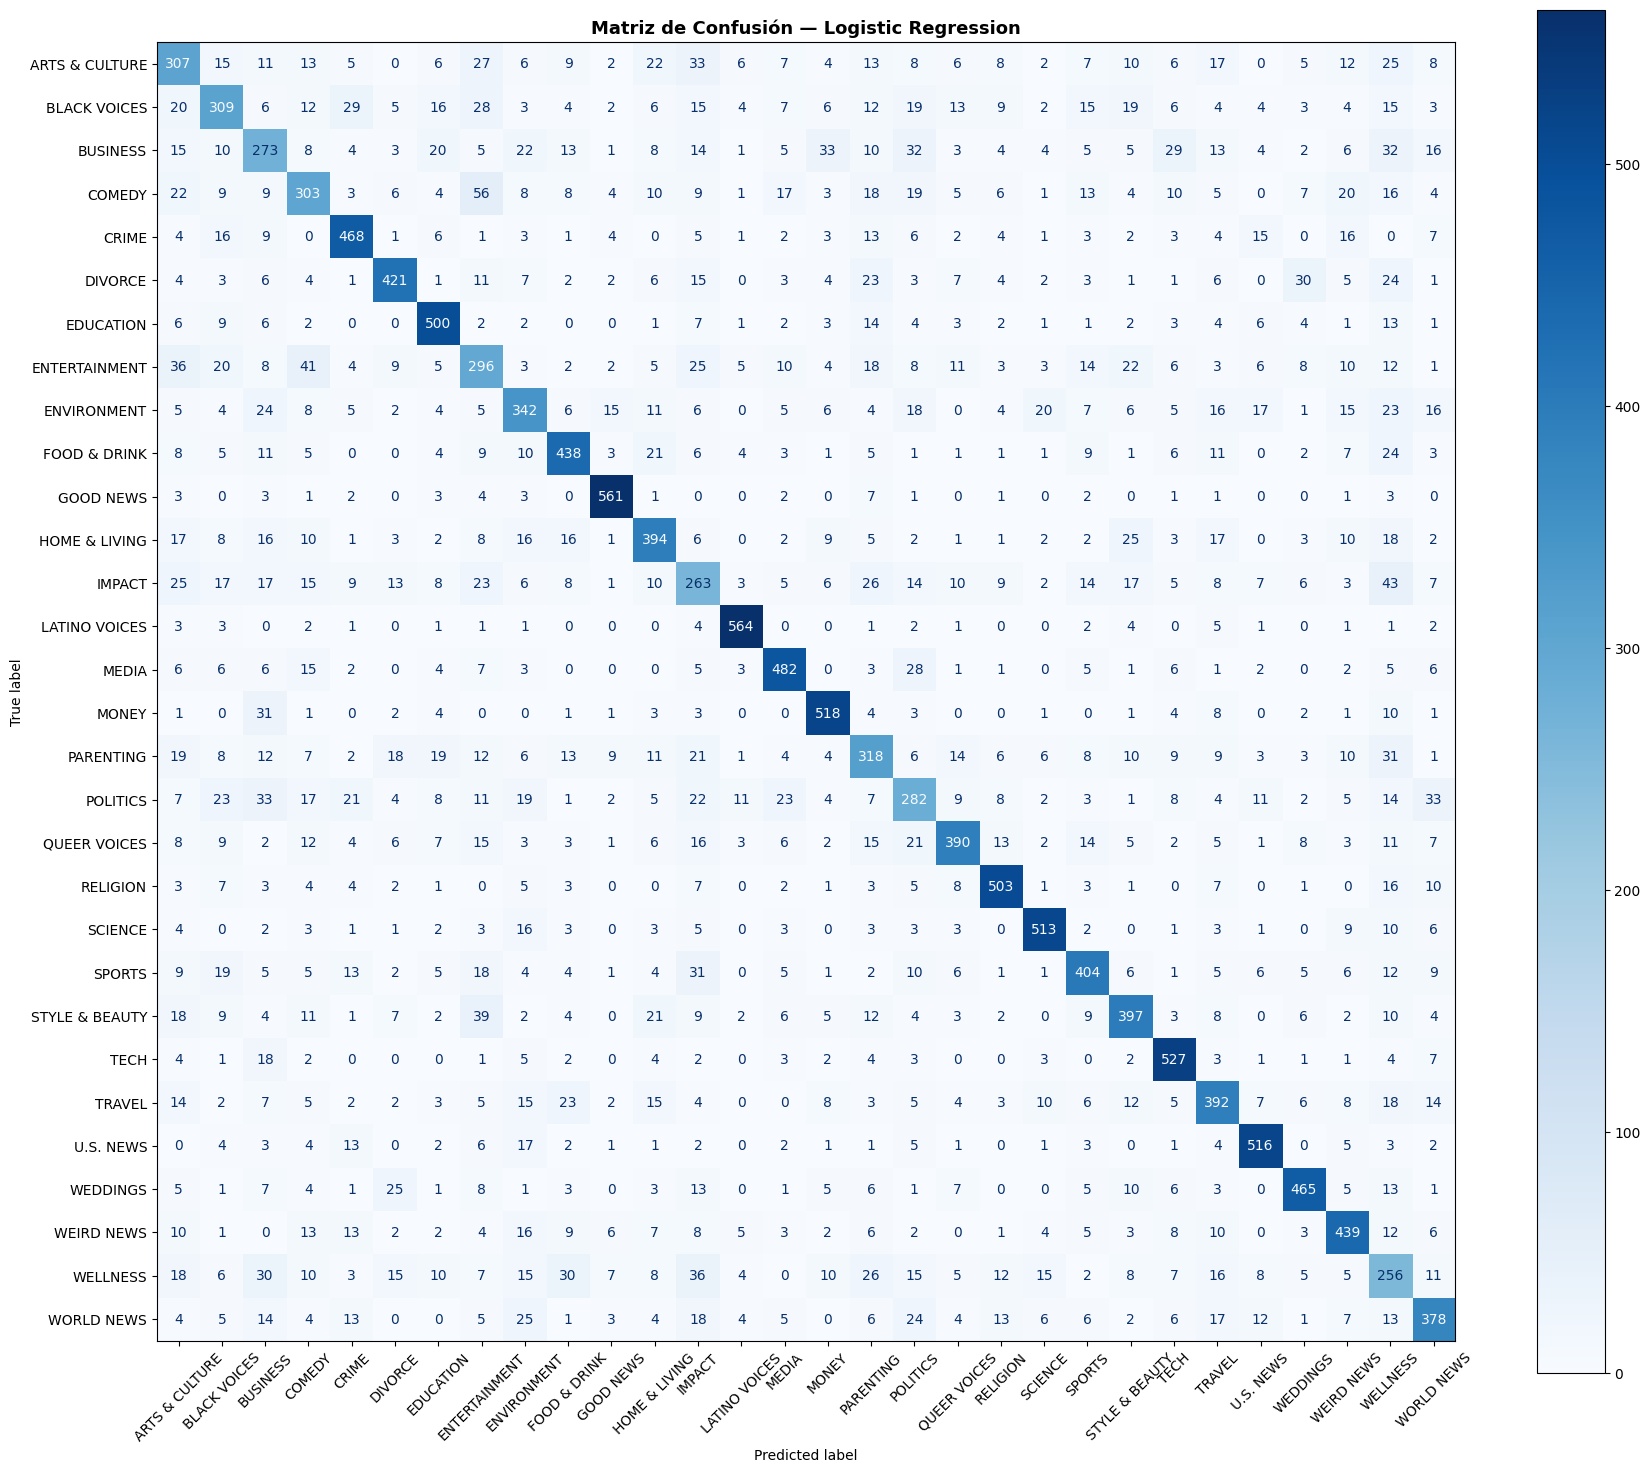

In [27]:

# FASE 2 — EVALUACIÓN FINAL sobre datos de prueba

evaluar_modelo(
        nombre        = 'Logistic Regression',
        grid_search   = gs_lr,
        X_te          = X_test_sc,
        y_te          = y_test,
        label_encoder = le
    )

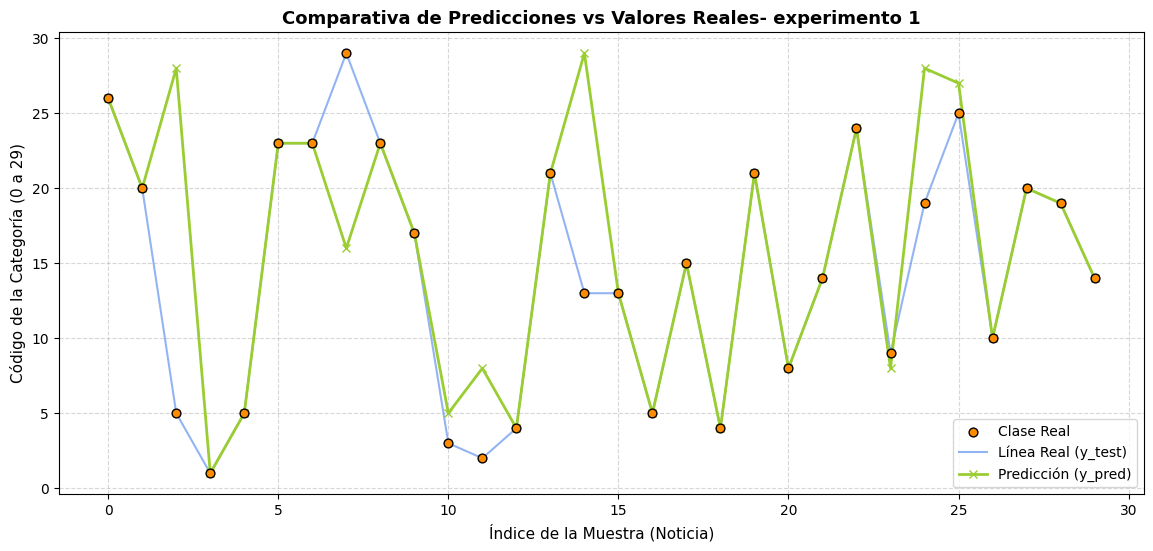

In [37]:
import numpy as np
import matplotlib.pyplot as plt

y_test_predict = gs_lr.predict(X_test_sc)

CANTIDAD_MUESTRAS = 30

x_eje = np.arange(0, CANTIDAD_MUESTRAS)[:, np.newaxis]

plt.figure(figsize=(14, 6))

# Graficar los puntos reales como esferas naranjas
plt.scatter(x_eje, y_test[:CANTIDAD_MUESTRAS], s=40, edgecolor="black", c="darkorange", zorder=3, label="Clase Real")

plt.plot(x_eje, y_test[:CANTIDAD_MUESTRAS], color="cornflowerblue", label="Línea Real (y_test)", linewidth=1.5, alpha=0.7)

plt.plot(x_eje, y_test_predict[:CANTIDAD_MUESTRAS], color="yellowgreen", label="Predicción (y_pred)", linewidth=2, marker='x')

plt.xlabel("Índice de la Muestra (Noticia)", fontsize=11)
plt.ylabel("Código de la Categoría (0 a 29)", fontsize=11)
plt.title("Comparativa de Predicciones vs Valores Reales- experimento 1", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

#### Conclusiones del Experimento 1: Clasificación de Noticias con Regresión Logística

Tras el rediseño del pipeline de procesamiento, la reestructuración del vocabulario y la optimización de hiperparámetros mediante `GridSearchCV`, se extraen las siguientes conclusiones fundamentales sobre el rendimiento del modelo:

#### 1. 

* **Poder Predictivo Multiclase:** Para un problema de clasificación de texto de alta complejidad que involucra **30 categorías mutuamente excluyentes**, un rendimiento cercano al 68% es estadísticamente robusto (considerando que una asignación aleatoria ofrecería apenas un 3.33% de aciertos).


#### 2.
* **Configuración Ganadora:** El proceso iterativo determinó que la mejor combinación de parámetros corresponde a `{C: 5, class_weight: 'balanced', penalty: 'l2'}`.
* **Comportamiento de la Regularización:** Un valor de $C = 5$ indica que el modelo se beneficia de una penalización moderadamente baja, permitiendo que los coeficientes se ajusten con mayor firmeza a los términos discriminativos clave sin llegar a memorizar el ruido de fondo.

#### 3.
* **Alta Densidad de Coincidencia:** La proyección gráfica de las primeras 30 muestras evidencia un solapamiento constante entre la `Clase Real` y la `Predicción`. El modelo replica con precisión la variabilidad estructural y las tendencias de asignación de los datos reales.
* **Naturaleza de los Errores:** Los desvíos puntuales (donde las líneas divergen marcadamente) se atribuyen a la superposición semántica natural entre categorías complejas (ej. *Wellness* vs *Healthy Living* o *Impact*). Al tratarse de un clasificador lineal, pequeños cambios en la frecuencia de ciertas palabras sesgan la frontera de decisión, un comportamiento esperado en arquitecturas basadas puramente en bolsas de palabras de frecuencias lineales.

### Conclusión
El modelo logra una separación efectiva en categorías con dominio léxico
propio (tecnología, religión, crimen, deportes). Las confusiones se concentran
en pares temáticamente adyacentes, un comportamiento esperable en un clasificador
lineal sobre 30 clases. Estos pares serán el indicador clave para evaluar
si modelos no lineales (Random Forest, MLP) logran mayor separación.

### 4.5 MODELO 2 — RANDOM FOREST 

#### Descripción General

**Random Forest** es un **ensemble** (conjunto) de árboles de decisión que mitiga el problema de sobreajuste del árbol individual. Cada árbol se entrena en una **muestra bootstrap** (con reemplazo) del dataset, y en cada nodo utiliza un subconjunto aleatorio de características para la división. Las predicciones finales se obtienen mediante **agregación por votación mayoritaria** (clasificación).


###  Hiperparámetros Utilizados - experimento 1

| Hiperparámetro | Valor(es) Probado(s) | Justificación |
|---|---|---|
| **n_estimators** | [200, 300] | Número de árboles; más = mejor pero costoso |
| **max_depth** | None | Permite que cada árbol crezca sin límite |
| **max_features** | 'sqrt' | √(15,000) ≈ 122 características por nodo |
| **min_samples_leaf** | [1, 2] | Profundidad — balance sesgo/varianza |
| **class_weight** | 'balanced' | Ajusta por desbalance de clases |
| **n_jobs** | -1 | Paralelización en múltiples núcleos CPU |
| **random_state** | 42 | Reproducibilidad |

In [ ]:

param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None],       # ← sin límite, deja crecer el árbol completo
    'max_features'    : ['sqrt'],     # mantener
    'min_samples_leaf': [1, 2],       # ← era 5, aquí está el problema principal
    'class_weight'    : ['balanced']
}

rf_base = RandomForestClassifier(
    random_state = RANDOM_STATE,
    n_jobs       = -1   
)

gs_rf = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid_rf,
    cv         = cv_strategy,     
    scoring    = SCORING,         
    refit      = True,
    n_jobs     = 1,               
    verbose    = VERBOSE
)

n_combos_rf = (len(param_grid_rf['n_estimators']) *
               len(param_grid_rf['max_depth']))

print("─" * 55)
print("  RANDOM FOREST — Fase 1")
print("─" * 55)
print(f"  Combinaciones : {n_combos_rf}  ×  {CV_FOLDS} folds  =  {n_combos_rf * CV_FOLDS} ajustes")
print(f"  Features      : {X_train_sc.shape[1]:,}")
print(f"  Muestras train: {X_train_sc.shape[0]:,}")
print("  Iniciando búsqueda …\n")

if __name__ == '__main__':
    t0_rf = time.time()
    gs_rf.fit(X_train_sc, y_train)
    tiempo_rf = time.time() - t0_rf

    print("\n" + "═" * 55)
    print("  RESULTADO DEL AJUSTE — Random Forest")
    print("═" * 55)
    print(f"  Mejor combinación  : {gs_rf.best_params_}")
    print(f"  Accuracy en CV     : {gs_rf.best_score_:.4f}")
    print(f"  Tiempo de búsqueda : {tiempo_rf / 60:.1f} min")
    print("─" * 55)

    # ── Comparativa rápida con LR ─────────────────────────────────────────
    lr_cv = resultados['Logistic Regression']['best_cv_score']
    delta = gs_rf.best_score_ - lr_cv
    signo = "+" if delta >= 0 else ""
    print(f"\n  Δ vs Logistic Regression (CV): {signo}{delta:.4f}")
    print("─" * 55)

───────────────────────────────────────────────────────
  RANDOM FOREST — Fase 1
───────────────────────────────────────────────────────
  Combinaciones : 2  ×  5 folds  =  10 ajustes
  Features      : 30,000
  Muestras train: 72,000
  Iniciando búsqueda …

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time= 5.0min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time= 4.0min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time= 3.5min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time= 4.7min
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=1, n_estimators=200; total time= 7.5min
[CV] END class_weight=balanced, max_depth=None, max_features=s

  RESULTADOS — Random Forest
  Mejores hiperparámetros : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
  Mejor accuracy (CV)     : 0.6176
  Accuracy en TEST        : 0.6351
  F1-macro  en TEST       : 0.6283
  Tiempo de refit         : 233.3 s

                precision    recall  f1-score   support

ARTS & CULTURE       0.37      0.48      0.42       600
  BLACK VOICES       0.54      0.38      0.44       600
      BUSINESS       0.45      0.35      0.39       600
        COMEDY       0.54      0.48      0.51       600
         CRIME       0.63      0.81      0.71       600
       DIVORCE       0.70      0.66      0.68       600
     EDUCATION       0.67      0.88      0.76       600
 ENTERTAINMENT       0.44      0.37      0.40       600
   ENVIRONMENT       0.52      0.52      0.52       600
  FOOD & DRINK       0.69      0.66      0.67       600
     GOOD NEWS       0.88      0.94      0.91       600
 HOME & LIVI

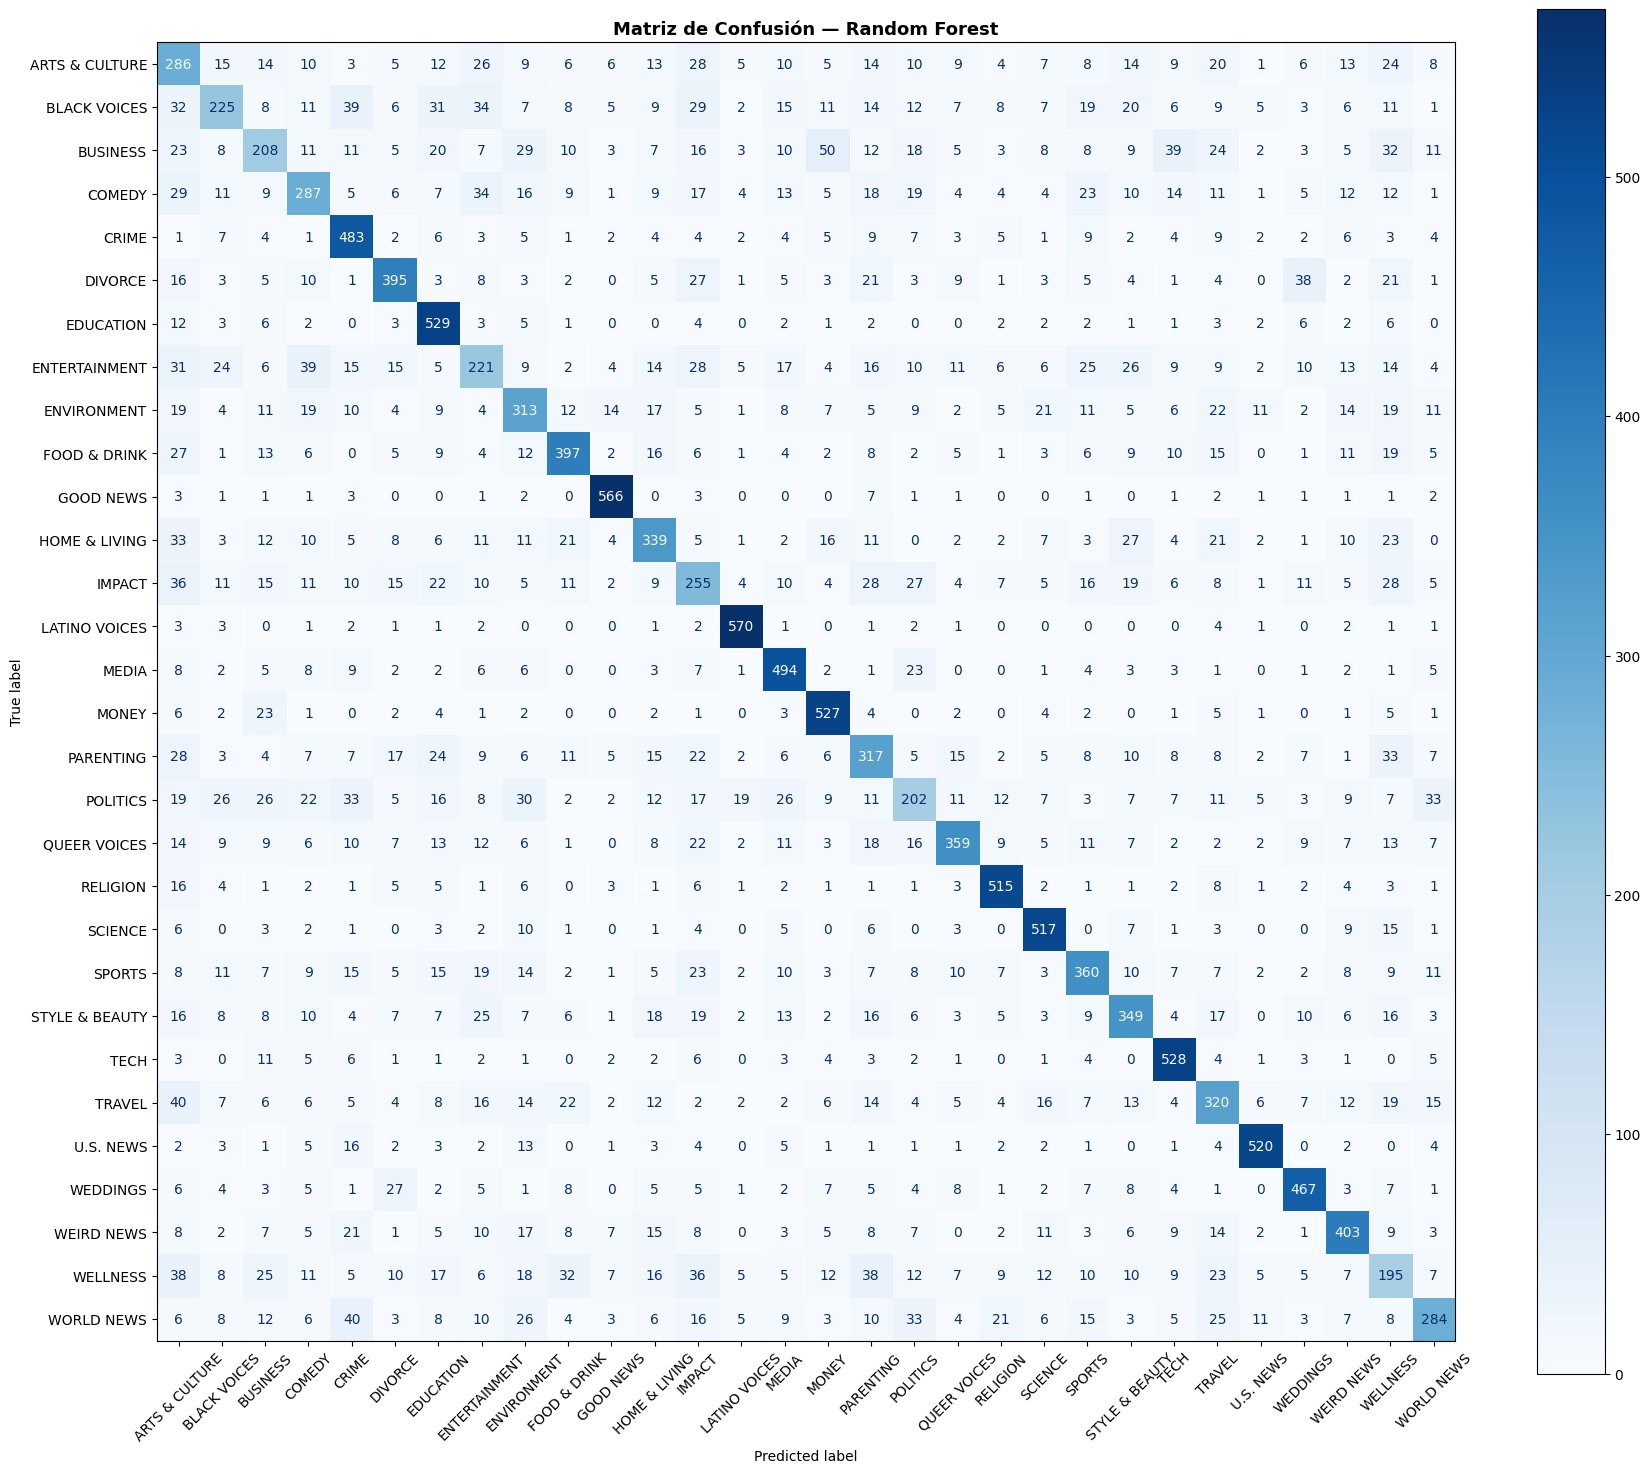

In [ ]:
# RANDOM FOREST — FASE 2: Evaluación final sobre X_test

if __name__ == '__main__':
    evaluar_modelo(
        nombre        = 'Random Forest',
        grid_search   = gs_rf,
        X_te          = X_test_sc,
        y_te          = y_test,
        label_encoder = le
    )


In [ ]:
y_test_predict_rf = gs_rf.predict(X_test_sc)

CANTIDAD_MUESTRAS = 30

x_eje = np.arange(0, CANTIDAD_MUESTRAS)[:, np.newaxis]

plt.figure(figsize=(14, 6))

# Graficar los puntos reales como esferas naranjas
plt.scatter(x_eje, y_test[:CANTIDAD_MUESTRAS], s=40, edgecolor="black", c="darkorange", zorder=3, label="Clase Real")

plt.plot(x_eje, y_test[:CANTIDAD_MUESTRAS], color="cornflowerblue", label="Línea Real (y_test)", linewidth=1.5, alpha=0.7)

plt.plot(x_eje, y_test_predict_rf[:CANTIDAD_MUESTRAS], color="yellowgreen", label="Predicción (y_pred)", linewidth=2, marker='x')

plt.xlabel("Índice de la Muestra (Noticia)", fontsize=11)
plt.ylabel("Código de la Categoría (0 a 29)", fontsize=11)
plt.title("Comparativa de Predicciones vs Valores Reales — Random Forest", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

### 5.2 Árbol de Decisión



#### Descripción General


Un **Árbol de Decisión** es un modelo no-paramétrico que particiona recursivamente el espacio de características mediante divisiones binarias basadas en criterios de impureza. Cada nodo interno representa una pregunta sobre una característica; cada rama representa una respuesta; cada hoja predice una etiqueta de clase.

Para el problema multiclase, el árbol automáticamente genera ramas para cada valor de característica hasta alcanzar nodos hoja puros (o con criterio de parada).

#### Hiperparámetros Utilizados - experimento 1

| Hiperparámetro | Valor(es) Probado(s) | Justificación |
|---|---|---|
| **max_depth** | [5, 10, 15, 20, None] | Controla la altura máxima; limita sobreajuste |
| **min_samples_split** | [2, 5, 10] | Mínimas muestras para dividir un nodo |
| **min_samples_leaf** | [1, 2, 5] | Mínimas muestras requeridas en un nodo hoja |
| **criterion** | Gini | Métrica de división |
| **class_weight** | 'balanced' | Penaliza menos a clases minoritarias |
| **random_state** | 42 | Reproducibilidad |


In [ ]:
param_grid_dt = {
    'max_depth'         : [5, 10, 15, 20, None],    # Controla altura máxima
    'min_samples_split' : [2, 5, 10],                # Mínimas muestras para dividir
    'min_samples_leaf'  : [1, 2, 5],                 # Mínimas muestras en hoja
    'criterion'         : ['gini'],                  # Métrica de impureza
    'class_weight'      : ['balanced']               # Penaliza clases minoritarias
}

dt_base = DecisionTreeClassifier(
    random_state = RANDOM_STATE
)

gs_dt = GridSearchCV(
    estimator  = dt_base,
    param_grid = param_grid_dt,
    cv         = cv_strategy,
    scoring    = SCORING,
    refit      = True,
    n_jobs     = N_JOBS,
    verbose    = VERBOSE
)

# ── Resumen de combinaciones
n_combos_dt = (len(param_grid_dt['max_depth']) * 
               len(param_grid_dt['min_samples_split']) * 
               len(param_grid_dt['min_samples_leaf']))

print("─" * 55)
print("  DECISION TREE — Fase 1")
print("─" * 55)
print(f"  Combinaciones : {n_combos_dt}  ×  {CV_FOLDS} folds  =  {n_combos_dt * CV_FOLDS} ajustes")
print(f"  Features      : {X_train_sc.shape[1]:,}")
print(f"  Muestras train: {X_train_sc.shape[0]:,}")
print("  Iniciando búsqueda …\n")

if __name__ == '__main__':
    t0_dt = time.time()
    gs_dt.fit(X_train_sc, y_train)
    tiempo_dt = time.time() - t0_dt

    print("\n" + "═" * 55)
    print("  RESULTADO DEL AJUSTE — Árbol de Decisión")
    print("═" * 55)
    print(f"  Mejor combinación  : {gs_dt.best_params_}")
    print(f"  Accuracy en CV     : {gs_dt.best_score_:.4f}")
    print(f"  Tiempo de búsqueda : {tiempo_dt / 60:.1f} min")
    print("─" * 55)

  

───────────────────────────────────────────────────────
  DECISION TREE — Fase 1
───────────────────────────────────────────────────────
  Combinaciones : 2  ×  5 folds  =  10 ajustes
  Features      : 30,000
  Muestras train: 72,000
  Iniciando búsqueda …

Fitting 5 folds for each of 8 candidates, totalling 40 fits

═══════════════════════════════════════════════════════
  RESULTADO DEL AJUSTE — Árbol de Decisión
═══════════════════════════════════════════════════════
  Mejor combinación  : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
  Accuracy en CV     : 0.5236
  Tiempo de búsqueda : 0.9 min
───────────────────────────────────────────────────────


  RESULTADOS — Decision Tree
  Mejores hiperparámetros : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
  Mejor accuracy (CV)     : 0.5236
  Accuracy en TEST        : 0.5559
  F1-macro  en TEST       : 0.5498
  Tiempo de refit         : 6.5 s

                precision    recall  f1-score   support

ARTS & CULTURE       0.25      0.37      0.30       600
  BLACK VOICES       0.35      0.32      0.33       600
      BUSINESS       0.30      0.29      0.29       600
        COMEDY       0.41      0.44      0.42       600
         CRIME       0.67      0.72      0.69       600
       DIVORCE       0.55      0.59      0.57       600
     EDUCATION       0.74      0.84      0.79       600
 ENTERTAINMENT       0.34      0.24      0.28       600
   ENVIRONMENT       0.40      0.38      0.39       600
  FOOD & DRINK       0.56      0.57      0.56       600
     GOOD NEWS       0.85      0.94      0.89 

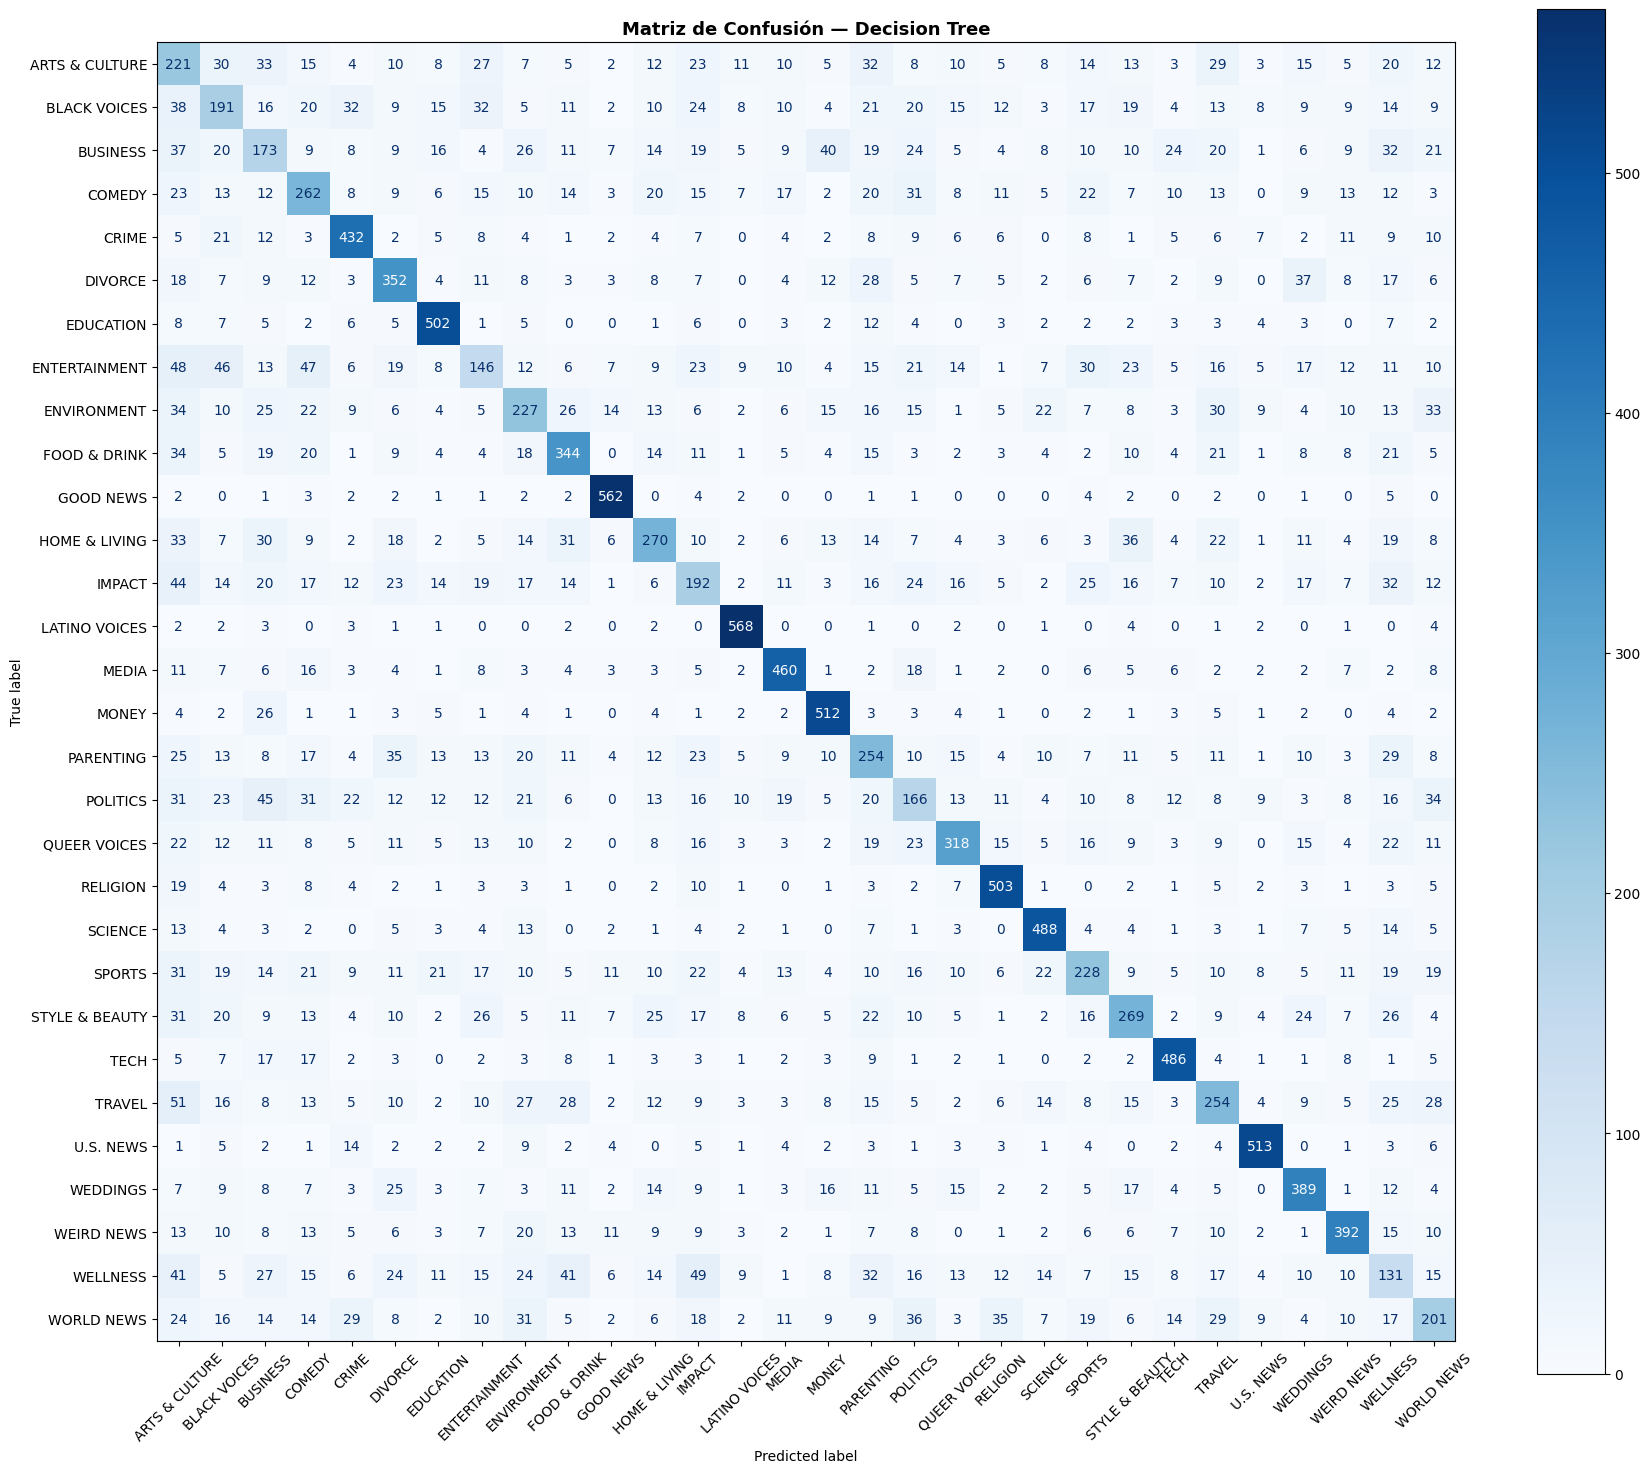

In [42]:
# DECISION TREE — FASE 2: Evaluación final sobre X_test

if __name__ == '__main__':
    evaluar_modelo(
        nombre        = 'Decision Tree',
        grid_search   = gs_dt,
        X_te          = X_test_sc,
        y_te          = y_test,
        label_encoder = le
    )

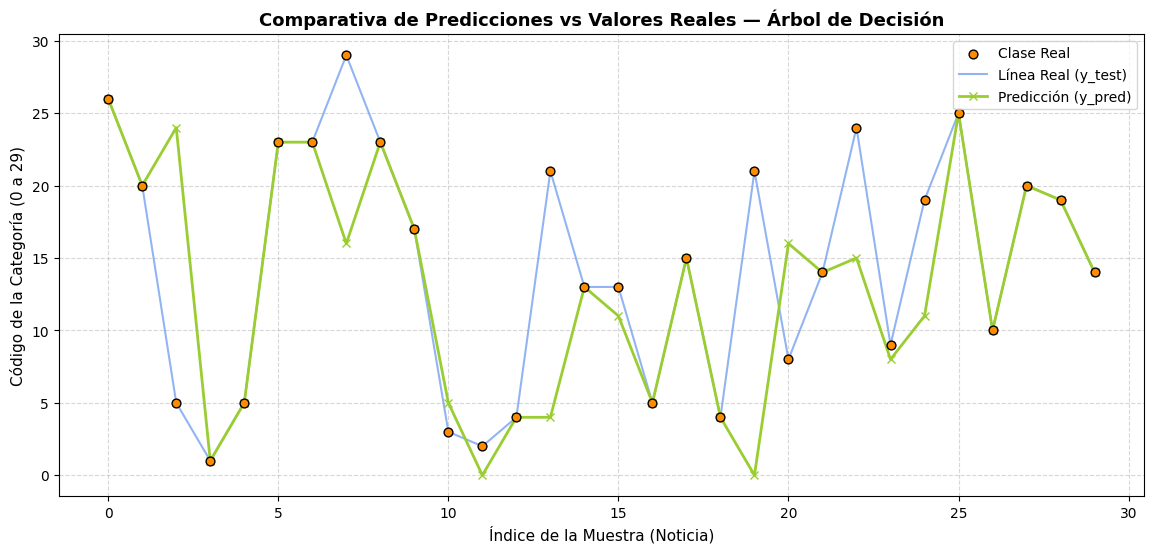

In [43]:
y_test_predict_dt = gs_dt.predict(X_test_sc)

CANTIDAD_MUESTRAS = 30

x_eje = np.arange(0, CANTIDAD_MUESTRAS)[:, np.newaxis]

plt.figure(figsize=(14, 6))

# Graficar los puntos reales como esferas naranjas
plt.scatter(x_eje, y_test[:CANTIDAD_MUESTRAS], s=40, edgecolor="black", c="darkorange", zorder=3, label="Clase Real")

plt.plot(x_eje, y_test[:CANTIDAD_MUESTRAS], color="cornflowerblue", label="Línea Real (y_test)", linewidth=1.5, alpha=0.7)

plt.plot(x_eje, y_test_predict_dt[:CANTIDAD_MUESTRAS], color="yellowgreen", label="Predicción (y_pred)", linewidth=2, marker='x')

plt.xlabel("Índice de la Muestra (Noticia)", fontsize=11)
plt.ylabel("Código de la Categoría (0 a 29)", fontsize=11)
plt.title("Comparativa de Predicciones vs Valores Reales — Árbol de Decisión", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

#### Hiperparámetros Utilizados - experimento 2

In [44]:
param_grid_dt = {
    'max_depth': [None, 50, 100],      # Controla altura máxima
    'min_samples_split': [2, 3],                
    'min_samples_leaf': [1, 2],                
    'criterion': ['gini', 'entropy'],  # En problemas de texto (NLP) con TF-IDF, la entropía suele dar mejores divisiones que Gini.
    'class_weight': [None, 'balanced'],
    'max_features': [None] 
}

dt_base = DecisionTreeClassifier(
    random_state = RANDOM_STATE
)

gs_dt = GridSearchCV(
    estimator  = dt_base,
    param_grid = param_grid_dt,
    cv         = cv_strategy,
    scoring    = SCORING,
    refit      = True,
    n_jobs     = N_JOBS,
    verbose    = VERBOSE
)

# ── Resumen de combinaciones
n_combos_dt = (len(param_grid_dt['max_depth']) * 
               len(param_grid_dt['min_samples_split']) * 
               len(param_grid_dt['min_samples_leaf']))

print("─" * 55)
print("  DECISION TREE — Fase 1")
print("─" * 55)
print(f"  Combinaciones : {n_combos_dt}  ×  {CV_FOLDS} folds  =  {n_combos_dt * CV_FOLDS} ajustes")
print(f"  Features      : {X_train_sc.shape[1]:,}")
print(f"  Muestras train: {X_train_sc.shape[0]:,}")
print("  Iniciando búsqueda …\n")

if __name__ == '__main__':
    t0_dt = time.time()
    gs_dt.fit(X_train_sc, y_train)
    tiempo_dt = time.time() - t0_dt

    print("\n" + "═" * 55)
    print("  RESULTADO DEL AJUSTE — Árbol de Decisión")
    print("═" * 55)
    print(f"  Mejor combinación  : {gs_dt.best_params_}")
    print(f"  Accuracy en CV     : {gs_dt.best_score_:.4f}")
    print(f"  Tiempo de búsqueda : {tiempo_dt / 60:.1f} min")
    print("─" * 55)

  

───────────────────────────────────────────────────────
  DECISION TREE — Fase 1
───────────────────────────────────────────────────────
  Combinaciones : 12  ×  5 folds  =  60 ajustes
  Features      : 30,000
  Muestras train: 72,000
  Iniciando búsqueda …

Fitting 5 folds for each of 48 candidates, totalling 240 fits

═══════════════════════════════════════════════════════
  RESULTADO DEL AJUSTE — Árbol de Decisión
═══════════════════════════════════════════════════════
  Mejor combinación  : {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Accuracy en CV     : 0.5712
  Tiempo de búsqueda : 23.8 min
───────────────────────────────────────────────────────


  RESULTADOS — Decision Tree
  Mejores hiperparámetros : {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Mejor accuracy (CV)     : 0.5712
  Accuracy en TEST        : 0.5958
  F1-macro  en TEST       : 0.5895
  Tiempo de refit         : 58.0 s

                precision    recall  f1-score   support

ARTS & CULTURE       0.30      0.44      0.36       600
  BLACK VOICES       0.39      0.34      0.36       600
      BUSINESS       0.37      0.30      0.33       600
        COMEDY       0.51      0.42      0.46       600
         CRIME       0.64      0.74      0.69       600
       DIVORCE       0.68      0.61      0.64       600
     EDUCATION       0.71      0.86      0.78       600
 ENTERTAINMENT       0.36      0.29      0.32       600
   ENVIRONMENT       0.46      0.48      0.47       600
  FOOD & DRINK       0.61      0.60      0.60       600
     GOOD NEWS       0.85      0.94      0.89       6

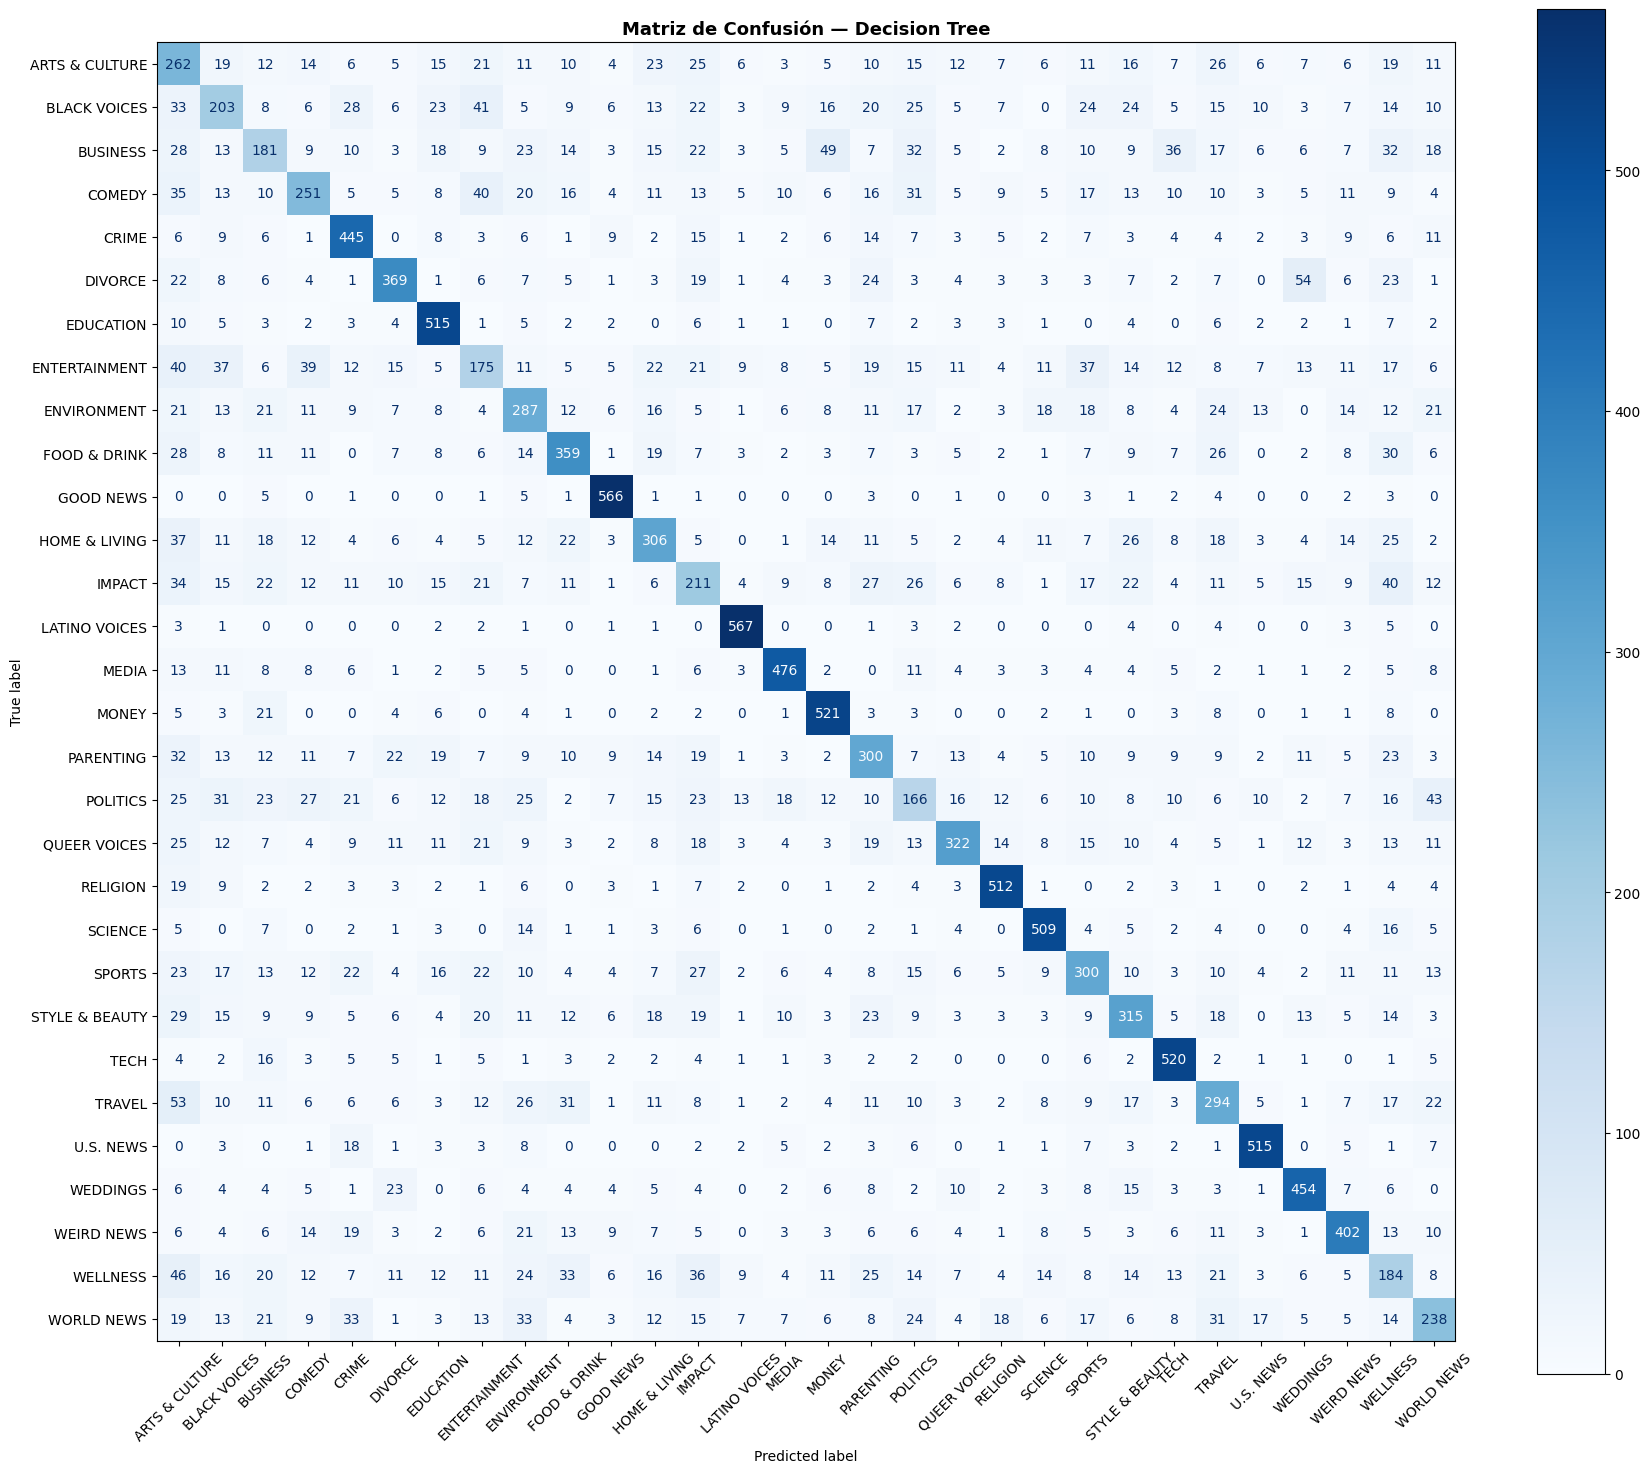

In [45]:
# DECISION TREE — FASE 2: Evaluación final sobre X_test

if __name__ == '__main__':
    evaluar_modelo(
        nombre        = 'Decision Tree',
        grid_search   = gs_dt,
        X_te          = X_test_sc,
        y_te          = y_test,
        label_encoder = le
    )

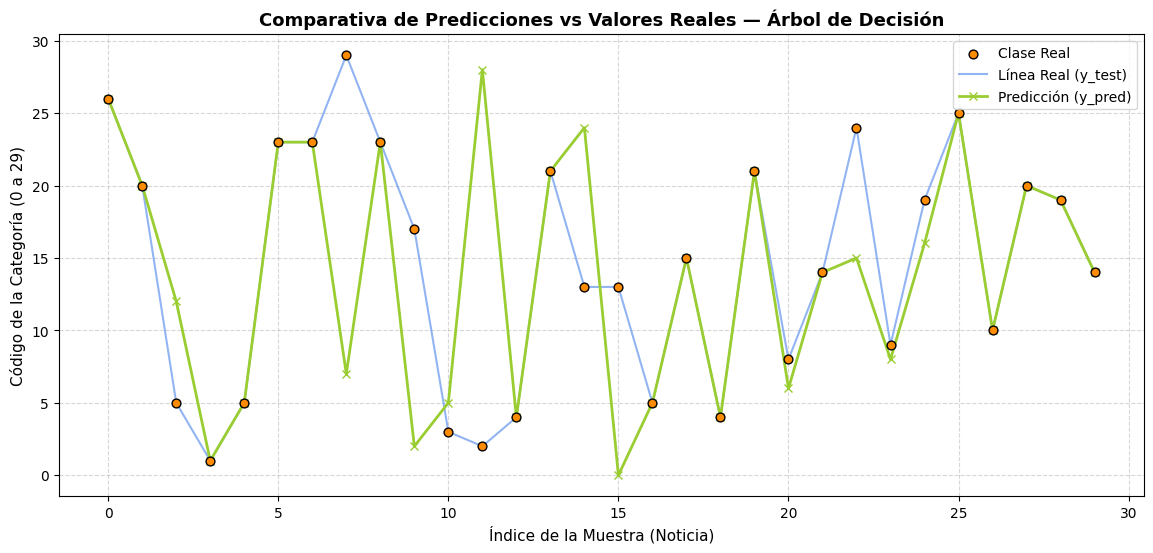

In [46]:
y_test_predict_dt = gs_dt.predict(X_test_sc)

CANTIDAD_MUESTRAS = 30

x_eje = np.arange(0, CANTIDAD_MUESTRAS)[:, np.newaxis]

plt.figure(figsize=(14, 6))

# Graficar los puntos reales como esferas naranjas
plt.scatter(x_eje, y_test[:CANTIDAD_MUESTRAS], s=40, edgecolor="black", c="darkorange", zorder=3, label="Clase Real")

plt.plot(x_eje, y_test[:CANTIDAD_MUESTRAS], color="cornflowerblue", label="Línea Real (y_test)", linewidth=1.5, alpha=0.7)

plt.plot(x_eje, y_test_predict_dt[:CANTIDAD_MUESTRAS], color="yellowgreen", label="Predicción (y_pred)", linewidth=2, marker='x')

plt.xlabel("Índice de la Muestra (Noticia)", fontsize=11)
plt.ylabel("Código de la Categoría (0 a 29)", fontsize=11)
plt.title("Comparativa de Predicciones vs Valores Reales — Árbol de Decisión", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

### 5.4 Red Neuronal — MLP (Multilayer Perceptron)

#### Descripción General

Un Perceptrón Multicapa (MLP) es una red neuronal artificial feedforward. Consiste en al menos tres capas de nodos: una capa de entrada, una capa oculta y una capa de salida. A excepción de los nodos de entrada, cada nodo es una neurona que utiliza una función de activación no lineal. MLP utiliza una técnica de aprendizaje supervisado llamada retropropagación para el entrenamiento. Su capacidad para aprender modelos no lineales lo hace muy poderoso para problemas de clasificación complejos.

#### Hiperparámetros Utilizados - experimento 1 (Ajustado para equipo: Intel Core i7-13700, 32 GB RAM)

Dado que las especificaciones del equipo cuentan con gran capacidad de CPU (i7 con 16 núcleos, 24 hilos) y alta memoria (32 GB RAM), podemos explotar la paralelización (con `n_jobs=-1`, utilizando todos los hilos) para reducir rápidamente el tiempo de procesamiento. Nota: Scikit-learn (MLPClassifier) no utiliza GPU para entrenar, por lo que la RTX 4060 en este caso específico no impacta este modelo en particular, sin embargo, el procesador que dispone el PC es más que suficiente para correr unas buenas combinaciones:

| Hiperparámetro | Valor(es) Probado(s) | Justificación |
|---|---|---|
| **hidden_layer_sizes** | [(100,), (100, 50), (50, 50, 50)] | Prueba desde arquitecturas de red simples hasta un poco más profundas para el aprendizaje de representaciones. |
| **activation** | ['relu', 'tanh'] | Define cómo se activarán las neuronas ocultas. |
| **alpha** | [0.0001, 0.001, 0.01] | Término de penalización (regularización L2) para evitar sobreajuste. |
| **learning_rate** | ['constant', 'adaptive'] | Estrategia de tasa de aprendizaje para converger hacia el peso óptimo. |
| **max_iter** | [200, 500] | Número máximo de iteraciones permitidas, útiles junto con *early_stopping*. |
| **random_state** | 42 | Reproducibilidad de los resultados. |


In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(100,), (100, 50), (50, 50, 50)], 
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [200, 500]
}

mlp_base = MLPClassifier(
    random_state = RANDOM_STATE,
    early_stopping=True # Para parar antes si no hay mejora en las interaciones
)

gs_mlp = GridSearchCV(
    estimator  = mlp_base,
    param_grid = param_grid_mlp,
    cv         = cv_strategy,
    scoring    = SCORING,
    refit      = True,
    n_jobs     = N_JOBS,  # Aprovecharemos todos los 24 hilos del i7-13700 
    verbose    = VERBOSE
)

# ── Resumen de combinaciones
n_combos_mlp = (len(param_grid_mlp['hidden_layer_sizes']) * 
                len(param_grid_mlp['activation']) * 
                len(param_grid_mlp['alpha']) * 
                len(param_grid_mlp['learning_rate']) * 
                len(param_grid_mlp['max_iter']))

print("─" * 55)
print("  MULTI-LAYER PERCEPTRON (MLP) — Fase 1")
print("─" * 55)
print(f"  Combinaciones : {n_combos_mlp}  ×  {CV_FOLDS} folds  =  {n_combos_mlp * CV_FOLDS} ajustes")
print(f"  Features      : {X_train_sc.shape[1]:,}")
print(f"  Muestras train: {X_train_sc.shape[0]:,}")
print("  Iniciando búsqueda …\n")

if __name__ == '__main__':
    t0_mlp = time.time()
    gs_mlp.fit(X_train_sc, y_train)
    tiempo_mlp = time.time() - t0_mlp

    print("\n" + "═" * 55)
    print("  RESULTADO DEL AJUSTE — Red Neuronal (MLP)")
    print("═" * 55)
    print(f"  Mejor combinación  : {gs_mlp.best_params_}")
    print(f"  Accuracy en CV     : {gs_mlp.best_score_:.4f}")
    print(f"  Tiempo de búsqueda : {tiempo_mlp / 60:.1f} min")
    print("─" * 55)

In [ ]:
#Fase 2- Pruebas el data de prueba con los mejor Hiperparametros
evaluar_modelo(
    nombre        = 'Red Neuronal (MLP)',
    grid_search   = gs_mlp,
    X_te          = X_test_sc,
    y_te          = y_test,
    label_encoder = le
)

In [ ]:
#Grafica de prediccion para MLP

y_test_predict_mlp = gs_mlp.predict(X_test_sc)

CANTIDAD_MUESTRAS = 30

x_eje = np.arange(0, CANTIDAD_MUESTRAS)[:, np.newaxis]

plt.figure(figsize=(14, 6))

# Graficar los puntos reales como esferas naranjas
plt.scatter(x_eje, y_test[:CANTIDAD_MUESTRAS], s=40, edgecolor="black", c="darkorange", zorder=3, label="Clase Real")

plt.plot(x_eje, y_test[:CANTIDAD_MUESTRAS], color="cornflowerblue", label="Línea Real (y_test)", linewidth=1.5, alpha=0.7)

plt.plot(x_eje, y_test_predict_mlp[:CANTIDAD_MUESTRAS], color="yellowgreen", label="Predicción (y_pred)", linewidth=2, marker='x')

plt.xlabel("Índice de la Muestra (Noticia)", fontsize=11)
plt.ylabel("Código de la Categoría (0 a 29)", fontsize=11)
plt.title("Comparativa de Predicciones vs Valores Reales — Red Neuronal — MLP ", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

### 5.5 Red Neuronal Profunda — DNN (Deep Neural Network)



#### Descripción General

Coloca aqui la descripcion del algoritmo

#### Hiperparámetros Utilizados - experimento 1

Los hiperparametros para el experimento 1

In [ ]:
#Coloca el codigo del algoritmo de red nuronal - Similar a los otros 2 modelos

In [ ]:
#Fase 2- Pruebas el data de prueba con los mejor Hiperparametros
evaluar_modelo(
        nombre        = 'Logistic Regression',
        grid_search   = gs_lr,
        X_te          = X_test_sc,
        y_te          = y_test,
        label_encoder = le
    )

In [ ]:
#Grafica de predic

y_test_predict_dt = gs_dt.predict(X_test_sc)

CANTIDAD_MUESTRAS = 30

x_eje = np.arange(0, CANTIDAD_MUESTRAS)[:, np.newaxis]

plt.figure(figsize=(14, 6))

# Graficar los puntos reales como esferas naranjas
plt.scatter(x_eje, y_test[:CANTIDAD_MUESTRAS], s=40, edgecolor="black", c="darkorange", zorder=3, label="Clase Real")

plt.plot(x_eje, y_test[:CANTIDAD_MUESTRAS], color="cornflowerblue", label="Línea Real (y_test)", linewidth=1.5, alpha=0.7)

plt.plot(x_eje, y_test_predict_dt[:CANTIDAD_MUESTRAS], color="yellowgreen", label="Predicción (y_pred)", linewidth=2, marker='x')

plt.xlabel("Índice de la Muestra (Noticia)", fontsize=11)
plt.ylabel("Código de la Categoría (0 a 29)", fontsize=11)
plt.title("Comparativa de Predicciones vs Valores Reales — Red Neuronal — MLP ", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)

plt.show()

---
## 6. Evaluación de modelos

> **[REDACTAR]** Explica qué mide cada métrica en el contexto de este problema:
> - **Accuracy:** proporción de predicciones correctas sobre el total.
> - **Precision (macro):** promedio de precisión por clase — qué tan fiables son las predicciones positivas.
> - **Recall (macro):** promedio de sensibilidad por clase — qué tan bien detecta cada categoría.
> - **F1-score (macro):** media armónica de precision y recall, equilibra ambos.

> **[ANALIZAR — por cada matriz de confusión]**
> - ¿Qué categorías clasifica mejor cada modelo?
> - ¿Qué pares de categorías se confunden con mayor frecuencia? ¿Por qué (similitud semántica)?
> - ¿Hay categorías con bajo recall consistente en todos los modelos?
> 
> Responde estas preguntas para CADA uno de los 5 modelos.

---
# BLOQUE III — Comparación de modelos y conclusiones

## 7. Comparación de modelos

> **[REDACTAR]** Introduce esta sección explicando el criterio de comparación: se seleccionó F1-macro como métrica principal por ser más robusta ante el desbalance de clases que el accuracy simple.

---
## 8. Conclusiones y trabajo futuro

### 8.1 Conclusiones

> **[REDACTAR — mínimo 4 párrafos con terminología técnica]**
>
> **Párrafo 1 — Cumplimiento del objetivo:** indica si se logró el objetivo propuesto en la sección 1. Menciona el F1-macro alcanzado por el mejor modelo y compáralo con la meta planteada.
>
> **Párrafo 2 — Hallazgos técnicos clave:** discute qué modelo ganó y por qué (características del espacio de features TF-IDF + Chi², naturaleza lineal vs no-lineal del problema, capacidad de generalización). Menciona qué categorías resultaron más difíciles de clasificar y a qué atribuyes esto (similitud semántica, desbalance de clases).
>
> **Párrafo 3 — Rol del preprocesamiento y Chi-squared:** reflexiona sobre el impacto de la selección de features con Chi²: ¿redujo el tiempo de entrenamiento? ¿Afectó el rendimiento? ¿Qué haría diferente?
>
> **Párrafo 4 — Limitaciones del trabajo:** las representaciones TF-IDF son bolsas de palabras y no capturan el orden ni el contexto semántico. El dataset está en inglés y desbalanceado. GridSearchCV con pocos valores de hiperparámetros puede no encontrar el óptimo global.

### 8.2 Trabajo futuro

> **[REDACTAR — mínimo 3 propuestas concretas]**
>
> - **Embeddings contextuales:** experimentar con modelos preentrenados como DistilBERT o RoBERTa para capturar relaciones semánticas que TF-IDF no puede representar.
> - **Balanceo de clases:** aplicar técnicas como oversampling con SMOTE adaptado para texto (usando embeddings) o class weights en la función de pérdida.
> - **Despliegue en producción:** desarrollar una API REST con FastAPI que reciba el texto de una noticia y devuelva la categoría predicha con su probabilidad, permitiendo integración con portales digitales.

---
## Referencias

1. Etminan, B. (2022). *News Category Classification Dataset*. Kaggle. https://www.kaggle.com/datasets/bornaetminan/news-category-classification-dataset
2. [AGREGAR] Referencia de paper sobre clasificación de texto en NLP.
3. [AGREGAR] Referencia de libro o artículo sobre Machine Learning supervisado.
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
5. Chollet, F. et al. (2015). *Keras*. https://keras.io